# Dekonstruksi Paradoks Ketahanan Pangan di Kepulauan Maluku

### Segmentasi Spasial 21 Kabupaten/Kota Berbasis Clustering Multi-Algoritma

**GEMASTIK XIX / 2026 — Divisi Penambangan Data**
Provinsi Maluku & Maluku Utara · Panel 2020–2025 · Track A, Modul Clustering

---

## Ringkasan Eksekutif

Presiden mengumumkan swasembada pangan nasional pada Januari 2026. Namun di Maluku
dan Maluku Utara, **seluruh 21 kabupaten/kota tanpa kecuali** memiliki Prevalensi
Ketidakcukupan Konsumsi Pangan (PoU) di atas rata-rata nasional — rata-rata 31,0%
berbanding 7,89%, atau hampir empat kali lipat.

Analisis ini menjawab satu pertanyaan: **jika kapasitas produksi pangan lokal
memadai, mengapa konsumsinya tetap tidak cukup?**

**Empat temuan utama:**

1. **Kapasitas produksi hampir tidak menjelaskan kecukupan konsumsi** (r = +0,14),
   sedangkan isolasi maritim menjelaskannya jauh lebih kuat (r = +0,60). Hambatannya
   ada di distribusi, bukan di produksi.

2. **Terbentuk empat tipologi wilayah** yang berbeda secara struktural — dan
   tipologi ini menjelaskan **51% variasi PoU** antar kabupaten meskipun PoU sama
   sekali tidak dipakai untuk membentuknya.

3. **Enam kabupaten di Maluku Utara mengalami rawan konsumsi tanpa kemiskinan
   ekstrem** — PoU tertinggi (33,7%) dengan kemiskinan hanya 6,5%. Persoalannya
   bukan daya beli, melainkan ketersediaan fisik pangan. Ini temuan dengan implikasi
   kebijakan paling langsung: bantuan tunai bukan jawabannya.

4. **Pertumbuhan ekonomi tidak otomatis menetes ke ketahanan pangan.** Halmahera
   Tengah dan Halmahera Timur memiliki PDRB per kapita 3,3 kali rata-rata wilayah
   berkat enklave smelter nikel, namun PoU masih 26% dan akses air minum layak
   justru paling rendah di antara seluruh 21 unit.

---

## Kerangka Analisis

```
 Data mentah  →  Pembersihan  →  Rekayasa fitur  →  Reduksi dimensi
      ↓                                                    ↓
 Audit integritas                              Penentuan jumlah tipologi
                                                          ↓
                             Lima algoritma: 3 non-spasial vs 2 berkendala spasial
                                                          ↓
                             Evaluasi dua sumbu + validasi eksternal
                                                          ↓
                             Tipologi final  →  Uji paradoks  →  Serah terima
```

### Tiga keputusan metodologis yang menentukan

**Panel diperlakukan dua lapis.** Clustering utama memakai rata-rata 2021–2025.
Dengan hanya 21 unit, fluktuasi tahunan estimasi survei akan mendominasi struktur
cluster bila dipakai potongan satu tahun. Lapis kedua — penelusuran keanggotaan per
tahun — memberi dimensi temporal tanpa kerapuhan metode deret waktu pada seri
sependek enam titik.

**PoU sengaja dikeluarkan dari input clustering.** Cluster dibentuk murni dari
kondisi struktural, lalu PoU dipakai memvalidasinya secara independen. Bila PoU ikut
menjadi input, argumen paradoks menjadi sirkular dan tidak membuktikan apa pun.

**Ketetanggaan spasial memakai KNN, bukan Queen contiguity.** Mayoritas kabupaten di
kedua provinsi ini adalah pulau terpisah yang tidak bersinggungan batas darat. Queen
contiguity akan menghasilkan matriks yang hampir seluruhnya nol dan membuat seluruh
analisis spasial kehilangan makna.

---
## Persiapan Lingkungan

In [1]:
import warnings, os, datetime as dt
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, silhouette_samples, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor

import geopandas as gpd
from libpysal.weights import KNN, W
from spopt.region import Skater

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PALETTE = ["#2E86AB", "#E4572E", "#F3A712", "#28965A", "#8E5572", "#5C6672"]
sns.set_theme(style="whitegrid")
sns.set_palette(PALETTE)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 11,
                     "axes.titleweight": "bold", "figure.facecolor": "white"})
os.makedirs("output", exist_ok=True)
os.makedirs("output/gambar", exist_ok=True)


def simpan(fig, nama):
    """Simpan setiap visualisasi ke output/gambar sebagai PNG resolusi cetak."""
    fig.savefig(f"output/gambar/{nama}.png", dpi=200, bbox_inches="tight",
                facecolor="white")
    plt.show()

PARAM = {
    "EXCEL_PATH": "DATASET_GEMASTIK_2026.xlsx",
    "GEOJSON_PATH": "batas_maluku.geojson",
    "SHEET": "Data Tabular",
    "TAHUN_UTAMA": [2021, 2022, 2023, 2024, 2025],
    "TAHUN_SEMUA": [2020, 2021, 2022, 2023, 2024, 2025],
    "AMBANG_VIF": 10.0,
    "KNN_AWAL": 3,
    "SKATER_FLOOR": 2,
    "N_BOOTSTRAP": 300,
}

---
## Data dan Integritasnya

Dataset memuat 21 kabupaten/kota × 6 tahun (126 observasi) dengan 26 indikator dari
BPS, Bapanas, Kemenhub, dan Kemenkes. Panel seimbang — tidak ada unit yang hilang di
tahun mana pun.

### Dua kerusakan format yang ditemukan dan dipulihkan

Pemeriksaan awal menemukan **539 sel (16,5% isi tabel) rusak akibat penafsiran format
oleh perangkat lunak spreadsheet**, bukan akibat data yang memang tidak tersedia.
Keduanya dapat dipulihkan secara deterministik:

**Angka terbaca sebagai tanggal.** Nilai `31.01` ditafsirkan sebagai 31 Januari lalu
disimpan sebagai `2026-01-31`. Aturan pemulihan: bila tahun sama dengan tahun
berjalan, nilai asli adalah `hari + bulan/100`; bila bukan (misalnya `9073-06-01`),
nilai asli adalah `tahun + bulan/100`.

**Pemisah desimal hilang pada nilai besar.** Gini Ratio tersimpan `316` alih-alih
0,316. Produksi perikanan Maluku Tengah 2023 tercatat 152.760.205 ton — lebih besar
daripada total tangkapan nasional; nilai sebenarnya 152.760 ton. Diperbaiki melalui
penskalaan 10ᵏ terhadap rentang plausibel tiap indikator.

> **Catatan integritas.** Sel-sel ini adalah hasil rekonstruksi, bukan data mentah.
> Seluruh perubahan tercatat sel demi sel di `output/audit_pembersihan.csv` untuk
> diperiksa ulang terhadap sumber BPS.

In [2]:
KANDIDAT = [PARAM["EXCEL_PATH"], "data/DATASET_GEMASTIK_2026.xlsx",
            "/mnt/user-data/uploads/DATASET_GEMASTIK_2026.xlsx"]
path = next((p for p in KANDIDAT if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError(f"File Excel tidak ditemukan. Dicari di: {KANDIDAT}")

raw = pd.read_excel(path, sheet_name=PARAM["SHEET"])

RENAME = {
    "Provinsi": "provinsi", "Kab/Kota": "wilayah", "Tahun": "tahun",
    "Y_PoU (Persen)": "PoU",
    "X1_Produksi_Perikanan_Tangkap_Laut (Ton)": "perikanan_tangkap",
    "X2_Produksi_Padi (Ton)": "produksi_padi",
    "X4_NTP (Indeks)": "ntp",
    "X5_Persentase_Penduduk_Miskin (Persen)": "penduduk_miskin",
    "X6_Garis_Kemiskinan (Rp/Kapita/Bulan)": "garis_kemiskinan",
    "X7_Gini_Rasio (Indeks)": "gini",
    "X8_PDRB_per_Kapita_ADHB (Juta Rp)": "pdrb_kapita",
    "X9_Pangsa_Pengeluaran_Pangan (Persen)": "pangsa_pangan",
    "X10_Rata_Rata_Pengeluaran_Pangan (Juta Rp/Kapita/Bulan)": "pengeluaran_pangan",
    "X11_Persentase_Jalan_Kondisi_Mantap (Persen)": "jalan_mantap",
    "X12_Kepadatan_Penduduk (Jiwa/Km²)": "kepadatan",
    "X13_Jumlah_Pelabuhan_Utama (Unit)": "jml_pelabuhan",
    "X13_Kunjungan_Kapal_Tahunan (Unit)": "kunjungan_kapal",
    "X13_Jarak_ke_Pelabuhan_Induk (Km)": "jarak_pelabuhan",
    "X14_TPAK (Persen)": "tpak",
    "X15_Rata_Rata_Lama_Sekolah (Tahun)": "lama_sekolah",
    "X16_Rasio_Non_Angkatan_Kerja (Persen)": "non_angkatan_kerja",
    "X17_TPT (Persen)": "pengangguran",
    "X18_Tenaga_Kerja_Pertanian_Kehutanan_Perikanan (Persen)": "tk_pertanian",
    "X19_RT_Akses_Air_Minum_Layak (Persen)": "air_minum",
    "X20_RT_Akses_Sanitasi_Layak (Persen)": "sanitasi",
    "X21_Prevalensi_Balita_Stunting (Persen)": "stunting",
    "X22_UHH_Saat_Lahir (Tahun)": "usia_harapan_hidup",
    "X23_IPM (Indeks)": "ipm",
    "X24_Persen_Desa_Sinyal_4G5G (Persen)": "sinyal_4g",
}
raw = raw.rename(columns=RENAME)
INDIKATOR = [c for c in raw.columns if c not in ("provinsi", "wilayah", "tahun")]

print(f"Sumber   : {path}")
print(f"Dimensi  : {raw.shape[0]} observasi × {raw.shape[1]} kolom")
print(f"Cakupan  : {raw.wilayah.nunique()} kabupaten/kota, tahun "
      f"{raw.tahun.min()}–{raw.tahun.max()}")
print(f"Panel    : {'seimbang' if raw.groupby('wilayah').tahun.nunique().nunique() == 1 else 'TIDAK seimbang'}")

Sumber   : DATASET_GEMASTIK_2026.xlsx
Dimensi  : 126 observasi × 29 kolom
Cakupan  : 21 kabupaten/kota, tahun 2020–2025
Panel    : seimbang


In [3]:
# Rentang plausibel tiap indikator — dasar deteksi dan koreksi skala.
RENTANG = {
    "PoU": (0, 100), "perikanan_tangkap": (100, 500_000), "produksi_padi": (0, 200_000),
    "ntp": (80, 130), "penduduk_miskin": (0, 60), "garis_kemiskinan": (100_000, 1_500_000),
    "gini": (0.15, 0.60), "pdrb_kapita": (5, 300), "pangsa_pangan": (20, 80),
    "pengeluaran_pangan": (200, 1600), "jalan_mantap": (0, 100), "kepadatan": (1, 5000),
    "jml_pelabuhan": (1, 30), "kunjungan_kapal": (10, 60_000), "jarak_pelabuhan": (0, 2000),
    "tpak": (40, 90), "lama_sekolah": (3, 15), "non_angkatan_kerja": (10, 60),
    "pengangguran": (0, 30), "tk_pertanian": (0, 90), "air_minum": (0, 100),
    "sanitasi": (0, 100), "stunting": (0, 70), "usia_harapan_hidup": (50, 85),
    "ipm": (40, 95), "sinyal_4g": (0, 100),
}
TAHUN_BERJALAN = 2026


def pulihkan_tanggal(v):
    if isinstance(v, (dt.datetime, pd.Timestamp)):
        return ((v.day + v.month / 100) if v.year == TAHUN_BERJALAN
                else (v.year + v.month / 100)), True
    return pd.to_numeric(v, errors="coerce"), False


def bersihkan(df, rentang):
    out, log = df.copy(), []
    for kol, (lo, hi) in rentang.items():
        if kol not in df.columns:
            continue
        nilai_baru = []
        for i, v in df[kol].items():
            asli = v
            val, dari_tanggal = pulihkan_tanggal(v)
            if dari_tanggal:
                log.append((df.at[i, "wilayah"], df.at[i, "tahun"], kol,
                            str(asli), val, "tanggal → angka"))
            if pd.notna(val) and not (lo <= val <= hi):
                sebelum, terkoreksi = val, None
                for k in (-3, -1, -2, 3, 1, 2):
                    if lo <= val * 10 ** k <= hi:
                        terkoreksi = val * 10 ** k
                        break
                if terkoreksi is not None:
                    val = terkoreksi
                    log.append((df.at[i, "wilayah"], df.at[i, "tahun"], kol,
                                sebelum, val, f"koreksi skala 10^{k}"))
                else:
                    log.append((df.at[i, "wilayah"], df.at[i, "tahun"], kol,
                                sebelum, np.nan, "di luar rentang → kosong"))
                    val = np.nan
            nilai_baru.append(val)
        out[kol] = nilai_baru
    return out, pd.DataFrame(log, columns=["wilayah", "tahun", "indikator",
                                           "nilai_asli", "nilai_pulih", "jenis"])


df, audit = bersihkan(raw, RENTANG)
audit.to_csv("output/audit_pembersihan.csv", index=False)

total_sel = len(raw) * len(RENTANG)
ringkas_audit = audit.jenis.value_counts()
print(f"Sel dipulihkan: {len(audit)} dari {total_sel} ({len(audit)/total_sel:.1%})\n")
print(ringkas_audit.to_string())

Sel dipulihkan: 539 dari 3276 (16.5%)

jenis
koreksi skala 10^-3         257
tanggal → angka             165
koreksi skala 10^-1         113
di luar rentang → kosong      3
koreksi skala 10^3            1


### Verifikasi pemulihan

Uji terpenting bagi rekonstruksi: apakah nilai hasil pemulihan menyambung mulus
dengan deret tahun di sekitarnya? Bila hasilnya melompat tidak wajar, aturan
pemulihannya salah.

In [4]:
contoh = raw[raw.wilayah == "Kota Ambon"][["tahun", "lama_sekolah", "penduduk_miskin"]]
hasil = df[df.wilayah == "Kota Ambon"][["tahun", "lama_sekolah", "penduduk_miskin"]]
verifikasi = contoh.merge(hasil, on="tahun", suffixes=(" (mentah)", " (pulih)"))
print("Kota Ambon — deret sebelum dan sesudah pemulihan\n")
print(verifikasi.to_string(index=False))

Kota Ambon — deret sebelum dan sesudah pemulihan

 tahun lama_sekolah (mentah) penduduk_miskin (mentah)  lama_sekolah (pulih)  penduduk_miskin (pulih)
  2020                 11.92                     4.51                 11.92                     4.51
  2021   2026-02-12 00:00:00      2026-02-05 00:00:00                 12.02                     5.02
  2022                 12.21                     4.68                 12.21                     4.68
  2023                 12.22                     5.25                 12.22                     5.25
  2024                 12.24                     5.13                 12.24                     5.13
  2025                 12.37                     4.34                 12.37                     4.34


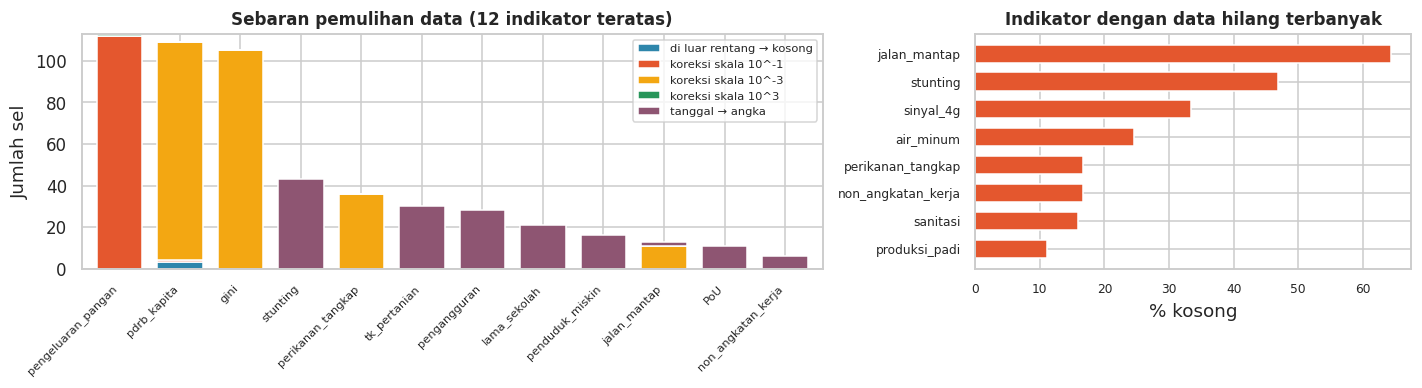

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6),
                         gridspec_kw={"width_ratios": [1.7, 1]})

cnt = audit.groupby(["indikator", "jenis"]).size().unstack(fill_value=0)
cnt = cnt.loc[cnt.sum(axis=1).sort_values(ascending=False).index].head(12)
cnt.plot(kind="bar", stacked=True, ax=axes[0], color=PALETTE[:cnt.shape[1]], width=.75)
axes[0].set(title="Sebaran pemulihan data (12 indikator teratas)",
            ylabel="Jumlah sel", xlabel="")
axes[0].legend(title="", fontsize=7.5)
axes[0].tick_params(axis="x", labelrotation=45, labelsize=7.5)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha("right")

kosong = (df[INDIKATOR].isna().mean() * 100).sort_values(ascending=False).head(8)
axes[1].barh(kosong.index[::-1], kosong.values[::-1], color="#E4572E", height=.65)
axes[1].set(title="Indikator dengan data hilang terbanyak", xlabel="% kosong")
axes[1].tick_params(labelsize=8)
plt.tight_layout(); simpan(fig, "01_audit_pembersihan")

### Keputusan atas indikator bermasalah

Audit menemukan tiga persoalan struktural yang memerlukan keputusan eksplisit:

| Indikator | Persoalan | Keputusan |
|---|---|---|
| `ntp`, `tk_pertanian` | Nilai identik untuk seluruh kabupaten dalam satu provinsi — indikator ini memang hanya dihitung BPS di level provinsi | Dijadikan variabel kontrol, dikeluarkan dari input clustering karena tidak dapat membedakan antar kabupaten |
| `jalan_mantap` | 64% hilang; empat kabupaten kosong sepenuhnya sehingga rata-rata multi-tahun mustahil dihitung | Dikeluarkan. Konsekuensinya, Indeks Aksesibilitas Fisik tereduksi menjadi konektivitas maritim saja — yang justru lebih tepat untuk wilayah kepulauan |
| `produksi_padi` | Kosong sepenuhnya di Kota Ternate dan Pulau Taliabu | Diisi nol; keduanya memang bukan wilayah penghasil padi |

In [6]:
PROVINSI_SAJA = [c for c in INDIKATOR
                 if df.groupby(["provinsi", "tahun"])[c].nunique().max() <= 1]
df["produksi_padi"] = df["produksi_padi"].fillna(0.0)
DIKELUARKAN = ["jalan_mantap"] + PROVINSI_SAJA

print(f"Terdeteksi hanya tersedia di level provinsi : {PROVINSI_SAJA}")
print(f"Dikeluarkan dari input clustering           : {DIKELUARKAN}")

Terdeteksi hanya tersedia di level provinsi : ['ntp', 'tk_pertanian']
Dikeluarkan dari input clustering           : ['jalan_mantap', 'ntp', 'tk_pertanian']


---
## Potret Awal: Seberapa Rawan Kepulauan Maluku?

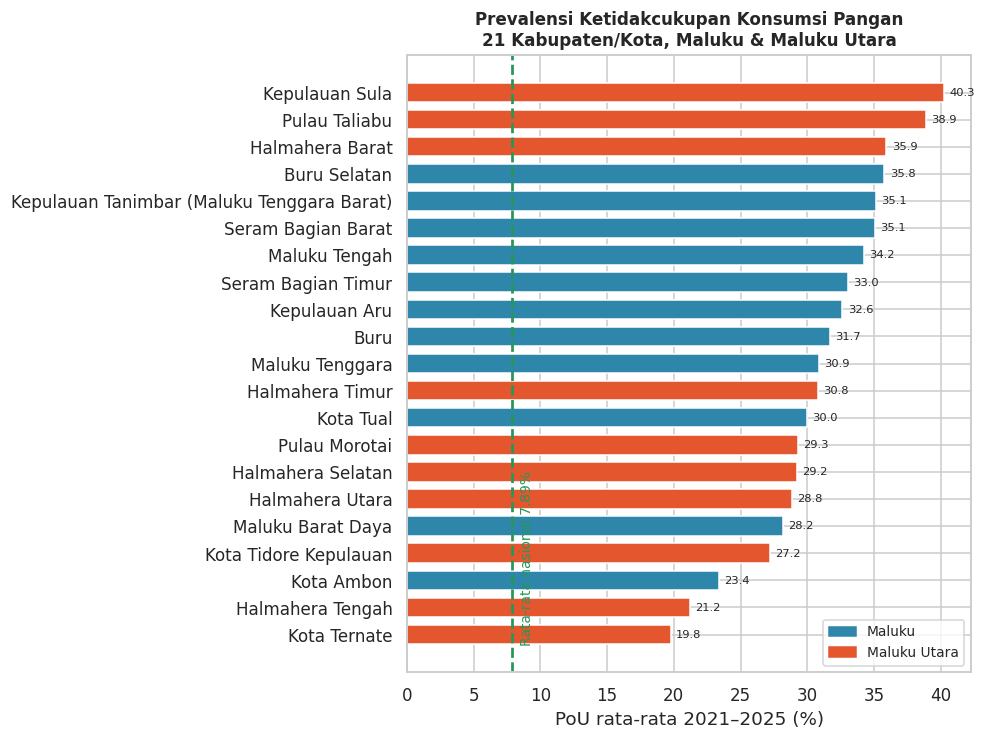

In [7]:
NASIONAL = 7.89
peringkat = (df[df.tahun.isin(PARAM["TAHUN_UTAMA"])]
             .groupby(["wilayah", "provinsi"])["PoU"].mean()
             .reset_index().sort_values("PoU"))

fig, ax = plt.subplots(figsize=(9, 6.8))
warna = ["#2E86AB" if p == "Maluku" else "#E4572E" for p in peringkat.provinsi]
bar = ax.barh(peringkat.wilayah, peringkat.PoU, color=warna, height=.72)
ax.axvline(NASIONAL, ls="--", c="#28965A", lw=1.8)
ax.text(NASIONAL + .6, -.4, f"Rata-rata nasional {NASIONAL}%",
        color="#28965A", fontsize=9, rotation=90, va="bottom")
for b, v in zip(bar, peringkat.PoU):
    ax.text(v + .4, b.get_y() + b.get_height() / 2, f"{v:.1f}", va="center", fontsize=7.5)
ax.set(xlabel="PoU rata-rata 2021–2025 (%)", ylabel="",
       title="Prevalensi Ketidakcukupan Konsumsi Pangan\n21 Kabupaten/Kota, Maluku & Maluku Utara")
ax.legend(handles=[mpatches.Patch(color="#2E86AB", label="Maluku"),
                   mpatches.Patch(color="#E4572E", label="Maluku Utara")],
          loc="lower right", fontsize=9)
plt.tight_layout(); simpan(fig, "02_peringkat_pou")

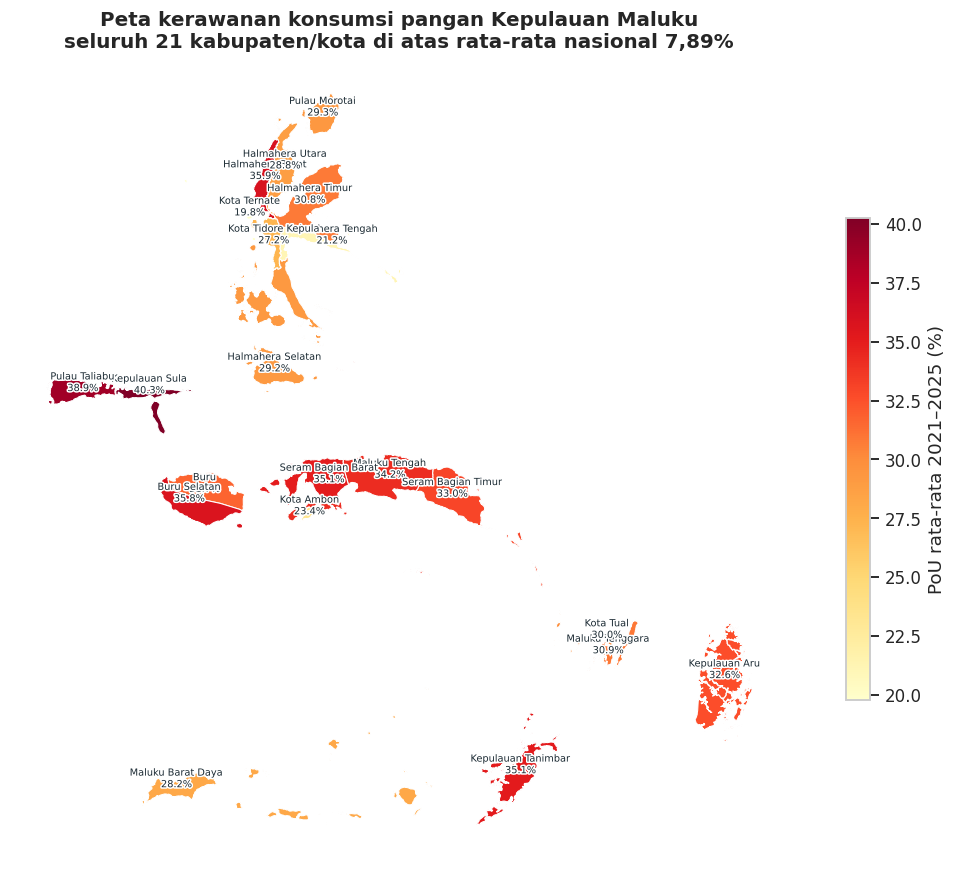

In [8]:
peta_pou = gpd.read_file(PARAM["GEOJSON_PATH"]).merge(
    peringkat[["wilayah", "PoU"]], on="wilayah", how="left")

fig, ax = plt.subplots(figsize=(11, 8))
peta_pou.plot(column="PoU", ax=ax, cmap="YlOrRd", edgecolor="white", linewidth=.7,
              legend=True, legend_kwds={"label": "PoU rata-rata 2021–2025 (%)",
                                        "shrink": .6})
for _, r in peta_pou.iterrows():
    ax.annotate(f"{r.wilayah[:18]}\n{r.PoU:.1f}%", (r.lon, r.lat), fontsize=6.4,
                ha="center", color="#1B2A33",
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])
ax.set_axis_off()
ax.set_title("Peta kerawanan konsumsi pangan Kepulauan Maluku\n"
             "seluruh 21 kabupaten/kota di atas rata-rata nasional 7,89%",
             fontsize=13)
plt.tight_layout(); simpan(fig, "03_peta_pou")

**Tidak ada satu pun pengecualian.** Seluruh 21 kabupaten/kota berada di atas
rata-rata nasional. Kepulauan Sula tertinggi dengan 40,3% — lebih dari lima kali
angka nasional — sementara Kota Ternate yang terendah pun masih 19,8%, dua setengah
kali lipat rata-rata nasional.

Rentang 20,5 poin persentase antara yang terbaik dan terburuk menunjukkan bahwa
wilayah ini jauh dari homogen. Justru ketimpangan internal inilah yang membuat
segmentasi tipologi bermakna: intervensi yang sama tidak akan bekerja untuk Kota
Ternate dan Pulau Taliabu.

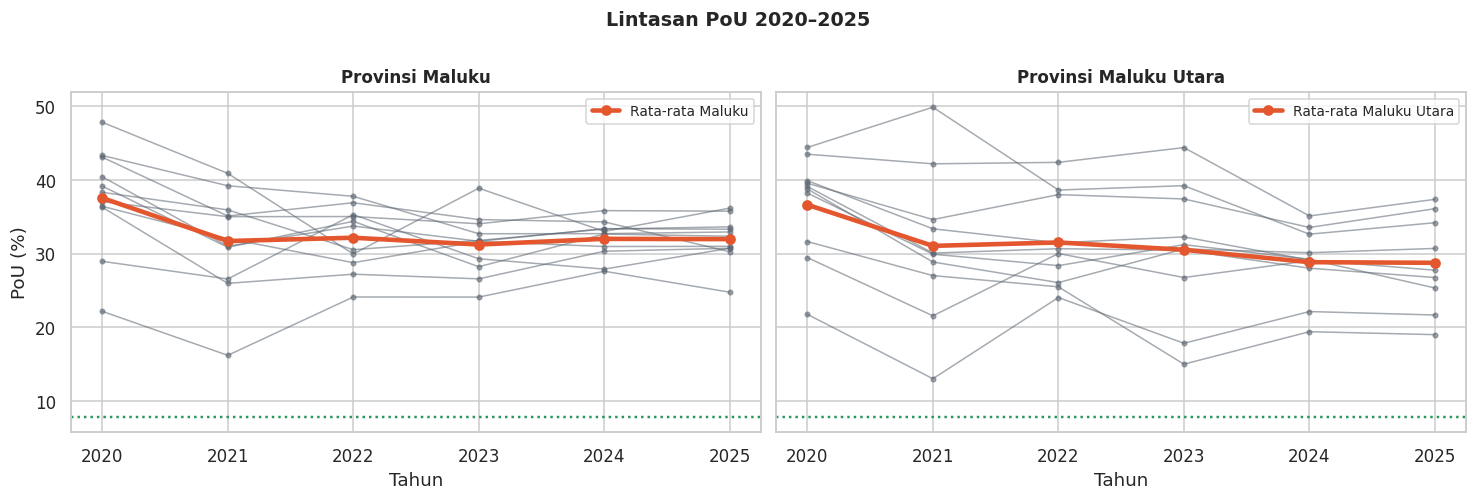

Membaik 2020→2025 : 19/21 kabupaten (terbesar Halmahera Utara, -12.9 poin)
Memburuk          : 2/21 kabupaten (terbesar Kota Ambon, +2.6 poin)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), sharey=True)
for ax, prov in zip(axes, ["Maluku", "Maluku Utara"]):
    sub = df[df.provinsi == prov]
    for w, g in sub.groupby("wilayah"):
        g = g.sort_values("tahun")
        ax.plot(g.tahun, g.PoU, marker="o", ms=3, lw=1, alpha=.55, color="#5C6672")
    rerata = sub.groupby("tahun").PoU.mean()
    ax.plot(rerata.index, rerata.values, color="#E4572E", lw=3, marker="o", ms=6,
            label=f"Rata-rata {prov}")
    ax.axhline(NASIONAL, ls=":", c="#28965A", lw=1.6)
    ax.set(title=f"Provinsi {prov}", xlabel="Tahun")
    ax.legend(fontsize=9)
axes[0].set_ylabel("PoU (%)")
plt.suptitle("Lintasan PoU 2020–2025", y=1.02, fontsize=12.5, fontweight="bold")
plt.tight_layout(); simpan(fig, "04_tren_pou")

perubahan = (df[df.tahun == 2025].set_index("wilayah").PoU
             - df[df.tahun == 2020].set_index("wilayah").PoU)
membaik, memburuk = int((perubahan < 0).sum()), int((perubahan > 0).sum())
print(f"Membaik 2020→2025 : {membaik}/21 kabupaten "
      f"(terbesar {perubahan.idxmin()}, {perubahan.min():.1f} poin)")
print(f"Memburuk          : {memburuk}/21 kabupaten "
      f"(terbesar {perubahan.idxmax()}, +{perubahan.max():.1f} poin)")

---
## Anatomi Wilayah: Apa yang Berkaitan dengan Kerawanan?

Sebelum membentuk tipologi, perlu dipahami dulu variabel mana yang bergerak
bersama PoU. Ini panduan awal, bukan kesimpulan kausal — pengujian kepentingan
variabel sesungguhnya dikerjakan pada tahap SHAP dan XGBoost oleh anggota tim lain.

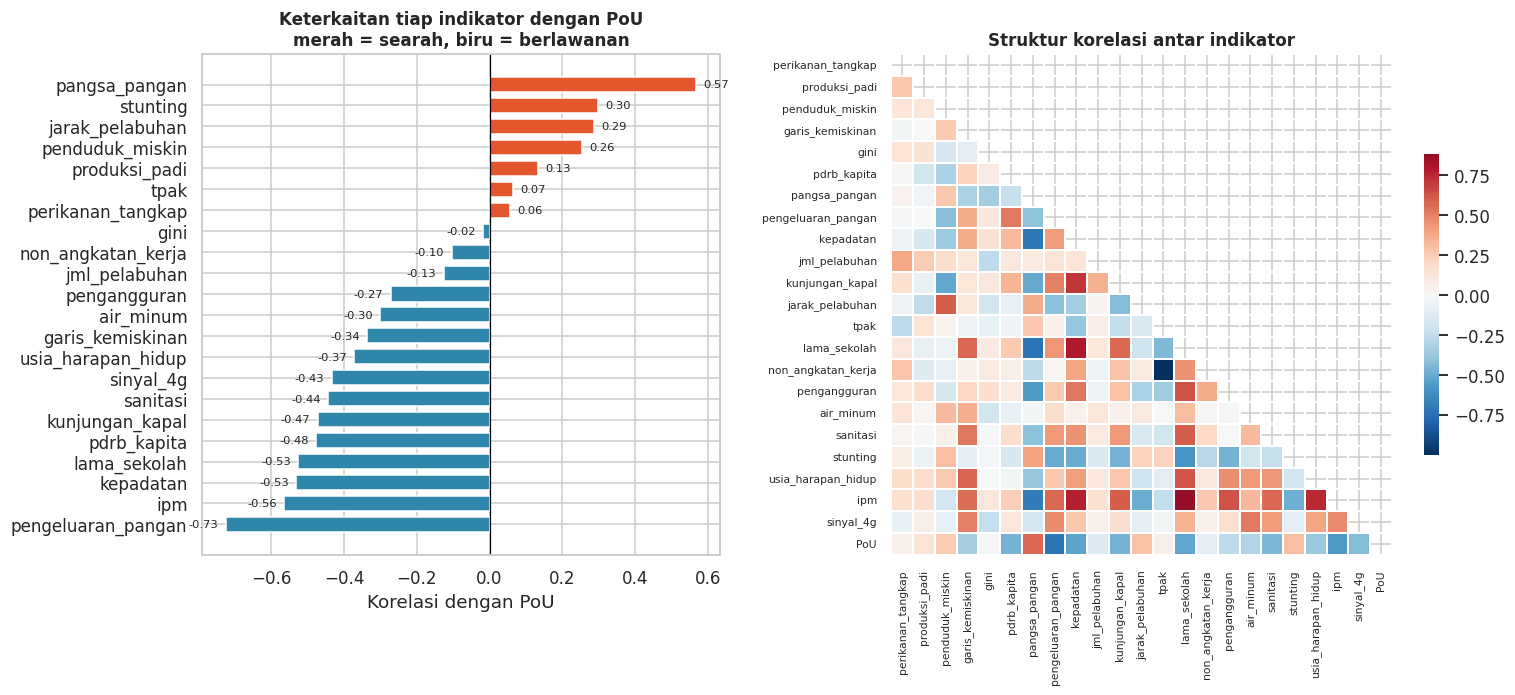

In [10]:
kol_eda = [c for c in INDIKATOR if c not in DIKELUARKAN + ["PoU"]]
korelasi = df[kol_eda + ["PoU"]].corr()["PoU"].drop("PoU").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2),
                         gridspec_kw={"width_ratios": [1, 1.25]})

warna = ["#E4572E" if v > 0 else "#2E86AB" for v in korelasi]
axes[0].barh(korelasi.index, korelasi.values, color=warna, height=.72)
axes[0].axvline(0, c="black", lw=.8)
for i, v in enumerate(korelasi.values):
    axes[0].text(v + (.02 if v > 0 else -.02), i, f"{v:.2f}", va="center",
                 ha="left" if v > 0 else "right", fontsize=7.5)
axes[0].set(xlabel="Korelasi dengan PoU", ylabel="",
            title="Keterkaitan tiap indikator dengan PoU\nmerah = searah, biru = berlawanan")

cm = df[kol_eda + ["PoU"]].corr()
sns.heatmap(cm, mask=np.triu(np.ones_like(cm, dtype=bool)), cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .6}, ax=axes[1], linewidths=.2)
axes[1].set_title("Struktur korelasi antar indikator")
axes[1].tick_params(labelsize=7)
plt.tight_layout(); simpan(fig, "05_korelasi_indikator")

Pola yang muncul konsisten: indikator **keterjangkauan dan kesejahteraan** —
pangsa pengeluaran pangan, IPM, lama sekolah, akses sanitasi — berkaitan paling
kuat dengan PoU. Sementara itu **produksi padi dan perikanan tangkap nyaris tidak
menunjukkan keterkaitan sama sekali**.

Petunjuk awal ini sudah mengarah ke tesis riset, tetapi belum membuktikannya.
Pembuktiannya memerlukan ukuran yang secara khusus menangkap keterhubungan dan
kapasitas produksi — yang belum tersedia langsung di data dan harus direkayasa.

---
## Merekayasa Ukuran Keterhubungan dan Kapasitas

### Indeks Konektivitas Maritim

Di provinsi daratan, persentase jalan kondisi mantap cukup mewakili aksesibilitas
fisik. Di kepulauan, ukuran itu tidak memadai: Kepulauan Aru dan Pulau Taliabu
bergantung sepenuhnya pada transportasi laut. Tanpa ukuran konektivitas maritim,
model akan menyimpulkan wilayah tersebut "cukup terhubung" padahal kenyataannya
sangat terisolasi.

$$IKM_i = w_1 \cdot norm(pelabuhan_i) + w_2 \cdot norm(kunjungan\ kapal_i) + w_3 \cdot norm\left(\frac{1}{jarak_i + 1}\right)$$

Bobot tidak ditetapkan berdasarkan dugaan, melainkan dikalibrasi dari muatan
komponen utama pertama. Kota Ambon dan Kota Ternate berjarak nol kilometer ke
pelabuhan induk karena keduanya *adalah* pelabuhan induk — karena itu inversi
jaraknya memakai $1/(jarak+1)$.

In [11]:
def normalisasi(s):
    s = pd.to_numeric(s, errors="coerce")
    rentang = s.max() - s.min()
    return pd.Series(.5, index=s.index) if (rentang == 0 or pd.isna(rentang)) \
        else (s - s.min()) / rentang


komponen_ikm = pd.DataFrame({
    "pelabuhan": df["jml_pelabuhan"],
    "kunjungan_kapal": df["kunjungan_kapal"],
    "kedekatan_pelabuhan": 1 / (df["jarak_pelabuhan"] + 1),
})
pc = PCA(n_components=1).fit(StandardScaler().fit_transform(komponen_ikm))
BOBOT = np.abs(pc.components_[0]) / np.abs(pc.components_[0]).sum()

df["IKM"] = sum(b * normalisasi(komponen_ikm[c])
                for b, c in zip(BOBOT, komponen_ikm.columns))
df["Isolasi"] = 1 - df["IKM"]

print(f"Komponen utama pertama menjelaskan {pc.explained_variance_ratio_[0]:.1%} "
      f"varians konektivitas\n")
for nm, b in zip(komponen_ikm.columns, BOBOT):
    print(f"   bobot {nm:<22} = {b:.3f}")

Komponen utama pertama menjelaskan 60.6% varians konektivitas

   bobot pelabuhan              = 0.223
   bobot kunjungan_kapal        = 0.407
   bobot kedekatan_pelabuhan    = 0.370


### Indeks Kapasitas Produksi Pangan

Rancangan awal riset memakai *Self-Sufficiency Ratio* — rasio total kalori produksi
lokal terhadap kebutuhan kalori penduduk. Ukuran itu **tidak dapat dihitung dari
dataset yang tersedia**, karena dua komponen kuncinya tidak ada: jumlah penduduk
per kabupaten dan produksi pangan lokal non-beras (sagu dan umbi-umbian), yang
justru merupakan pangan pokok riil di Maluku.

Sebagai gantinya dipakai **Indeks Kapasitas Produksi Pangan (IKPP)** — kapasitas
produksi *relatif* antar 21 unit, dari perikanan tangkap dan padi yang
ditransformasi logaritmik karena keduanya sangat menceng.

> **Batas klaim yang boleh ditegakkan.** IKPP menjawab "kabupaten mana yang
> kapasitas produksinya tinggi dibanding yang lain", bukan "apakah produksinya cukup
> secara absolut". Argumen paradoks yang dibangun karenanya bersifat komparatif
> antar 21 unit, bukan pernyataan tentang swasembada. Fungsi perhitungan SSR sudah
> disiapkan dan akan aktif otomatis begitu data populasi tersedia.

In [12]:
df["IKPP"] = (.5 * normalisasi(np.log1p(df["perikanan_tangkap"]))
              + .5 * normalisasi(np.log1p(df["produksi_padi"])))
df["Tekanan_Pangan"] = (df["pengeluaran_pangan"] * 1000) / df["garis_kemiskinan"]

KALORI = {"perikanan": 1000, "beras": 3600, "nonberas": 1200}
KEBUTUHAN_HARIAN = 2100


def hitung_ssr(d):
    """Rasio swasembada absolut. Aktif setelah kolom populasi tersedia."""
    if "populasi" not in d.columns:
        return None
    kalori = (d["perikanan_tangkap"] * 1000 * KALORI["perikanan"]
              + d["produksi_padi"] * 1000 * KALORI["beras"] * 0.65
              + d.get("pangan_lokal_nonberas", 0) * 1000 * KALORI["nonberas"])
    return kalori / (d["populasi"] * KEBUTUHAN_HARIAN * 365)


if (ssr := hitung_ssr(df)) is not None:
    df["SSR"] = ssr
    print("SSR absolut aktif.")
else:
    print("Kolom populasi belum tersedia — analisis memakai IKPP (kapasitas relatif).")

Kolom populasi belum tersedia — analisis memakai IKPP (kapasitas relatif).


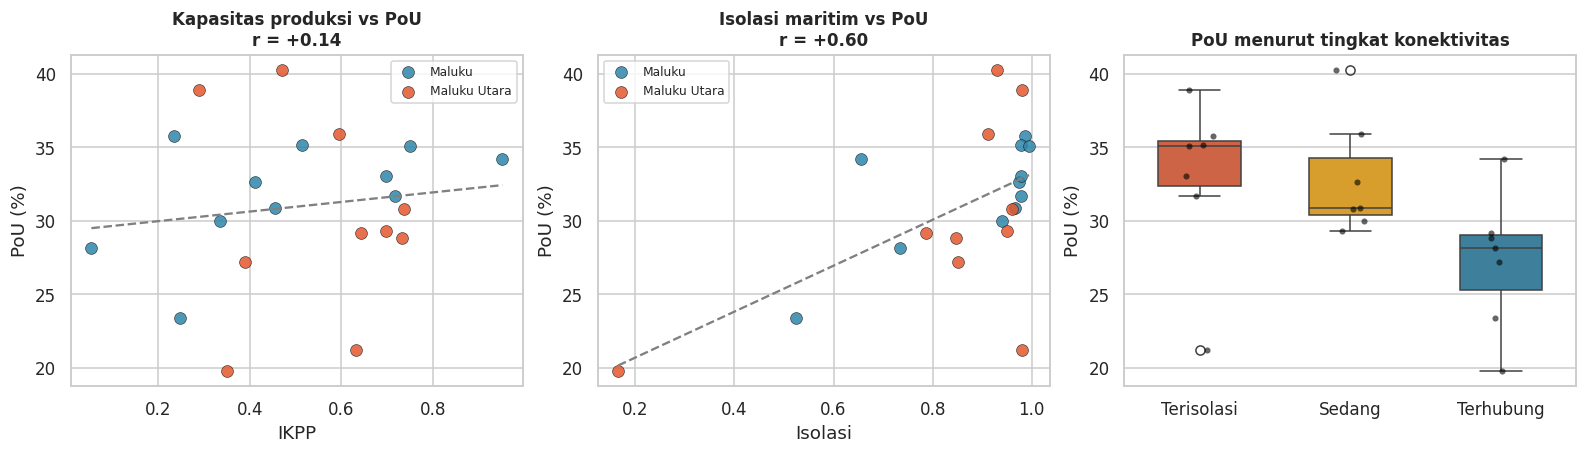

In [13]:
ringkas = (df[df.tahun.isin(PARAM["TAHUN_UTAMA"])]
           .groupby(["wilayah", "provinsi"])[["IKM", "Isolasi", "IKPP", "PoU"]]
           .mean().reset_index())

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
for ax, (x, judul) in zip(axes[:2], [("IKPP", "Kapasitas produksi"),
                                     ("Isolasi", "Isolasi maritim")]):
    for prov, col in [("Maluku", "#2E86AB"), ("Maluku Utara", "#E4572E")]:
        s = ringkas[ringkas.provinsi == prov]
        ax.scatter(s[x], s.PoU, c=col, s=60, alpha=.85, edgecolor="k", lw=.4, label=prov)
    r = ringkas[x].corr(ringkas.PoU)
    xs = np.linspace(ringkas[x].min(), ringkas[x].max(), 50)
    ax.plot(xs, np.polyval(np.polyfit(ringkas[x], ringkas.PoU, 1), xs), "--", c="grey")
    ax.set(xlabel=x, ylabel="PoU (%)", title=f"{judul} vs PoU\nr = {r:+.2f}")
    ax.legend(fontsize=8)

kelompok = ringkas.assign(tingkat=pd.qcut(ringkas.IKM, 3,
                                          labels=["Terisolasi", "Sedang", "Terhubung"]))
sns.boxplot(data=kelompok, x="tingkat", y="PoU", ax=axes[2],
            palette=["#E4572E", "#F3A712", "#2E86AB"], width=.55)
sns.stripplot(data=kelompok, x="tingkat", y="PoU", ax=axes[2], color="black",
              size=4, alpha=.6)
axes[2].set(title="PoU menurut tingkat konektivitas", xlabel="", ylabel="PoU (%)")
plt.tight_layout(); simpan(fig, "06_konektivitas_kapasitas")

Kontrasnya sudah terlihat bahkan sebelum clustering dilakukan: **kapasitas produksi
hampir tidak berhubungan dengan PoU, sedangkan isolasi maritim berhubungan kuat.**
Kelompok wilayah paling terhubung memiliki PoU jelas lebih rendah, dan pola ini
konsisten di kedua provinsi.

---
## Menyiapkan Ruang Analisis

Clustering dilakukan pada rata-rata 2021–2025. Sebelum itu, dua tahap penyiapan
wajib dilalui — dan keduanya bukan formalitas.

**Reduksi multikolinearitas.** Indikator kesejahteraan di data ini saling berkorelasi
sangat kuat. Bila dibiarkan, satu dimensi konseptual yang sama akan terhitung
berkali-kali dan mendistorsi jarak antar wilayah.

**Reduksi dimensi.** Dengan 21 observasi dan sekitar 20 indikator, jumlah dimensi
hampir menyamai jumlah unit. Pada kondisi ini jarak Euclidean kehilangan daya
pembeda — gejala yang dikenal sebagai *curse of dimensionality* — dan cluster apa pun
berisiko menjadi artefak.

In [14]:
FITUR_AWAL = [c for c in INDIKATOR if c not in DIKELUARKAN + ["PoU"]
              and c not in ("jml_pelabuhan", "kunjungan_kapal", "jarak_pelabuhan")]
FITUR_AWAL += ["IKM", "IKPP", "Tekanan_Pangan"]
TURUNAN = ["PoU", "IKM", "Isolasi", "IKPP", "Tekanan_Pangan"]

cs = (df[df.tahun.isin(PARAM["TAHUN_UTAMA"])]
      .groupby(["wilayah", "provinsi"], as_index=False)[
          list(dict.fromkeys(FITUR_AWAL + TURUNAN))].mean()
      .sort_values("wilayah").reset_index(drop=True))

# Batas wilayah administratif 21 kabupaten/kota, sumber Humanitarian Data Exchange.
# Centroid diturunkan dari poligon sungguhan, bukan aproksimasi titik ibu kota.
peta = gpd.read_file(PARAM["GEOJSON_PATH"]).to_crs(4326)
cs = cs.merge(peta[["wilayah", "kode", "lat", "lon"]], on="wilayah", how="left")
assert cs[["lat", "lon"]].notna().all().all(), "Ada wilayah tanpa geometri"
peta = peta.merge(cs[["wilayah", "PoU"]], on="wilayah", how="left")

print(f"Cross-section terbentuk: {cs.shape[0]} unit × {len(FITUR_AWAL)} indikator kandidat")
print(f"Nilai kosong tersisa   : {int(cs[FITUR_AWAL].isna().sum().sum())}")

Cross-section terbentuk: 21 unit × 22 indikator kandidat
Nilai kosong tersisa   : 0


In [15]:
def seleksi_vif(X, ambang=10.0):
    Xw, dibuang = X.copy().astype(float), []
    while Xw.shape[1] > 2:
        Xc = pd.DataFrame(StandardScaler().fit_transform(Xw), columns=Xw.columns)
        Xc.insert(0, "_const", 1.0)
        vif = pd.Series([variance_inflation_factor(Xc.values, i)
                         for i in range(1, Xc.shape[1])], index=Xw.columns)
        if vif.max() < ambang:
            break
        dibuang.append((vif.idxmax(), vif.max()))
        Xw = Xw.drop(columns=[vif.idxmax()])
    Xc = pd.DataFrame(StandardScaler().fit_transform(Xw), columns=Xw.columns)
    Xc.insert(0, "_const", 1.0)
    akhir = pd.Series([variance_inflation_factor(Xc.values, i)
                       for i in range(1, Xc.shape[1])],
                      index=Xw.columns).sort_values(ascending=False)
    return list(Xw.columns), dibuang, akhir


FITUR, DIBUANG, VIF_AKHIR = seleksi_vif(cs[FITUR_AWAL], PARAM["AMBANG_VIF"])
print(f"Dibuang karena multikolinearitas ({len(DIBUANG)} indikator):")
for nm, v in DIBUANG:
    print(f"   {nm:<22} VIF = {v:9.2f}")
print(f"\nTersisa {len(FITUR)} indikator, seluruhnya VIF < {PARAM['AMBANG_VIF']} "
      f"(tertinggi {VIF_AKHIR.max():.2f})")

Dibuang karena multikolinearitas (9 indikator):
   perikanan_tangkap      VIF =       inf
   produksi_padi          VIF =       inf
   non_angkatan_kerja     VIF =  39090.73
   Tekanan_Pangan         VIF =   2576.33
   lama_sekolah           VIF =    358.23
   pangsa_pangan          VIF =     26.59
   ipm                    VIF =     19.74
   kepadatan              VIF =     15.85
   pengangguran           VIF =     11.46

Tersisa 13 indikator, seluruhnya VIF < 10.0 (tertinggi 7.80)


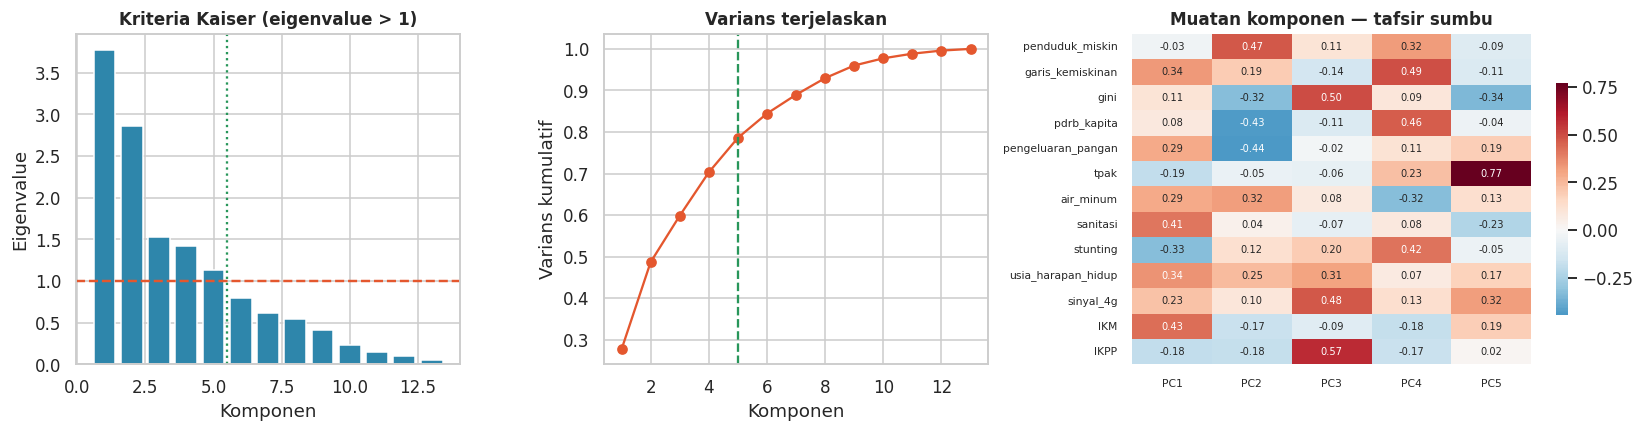

Kriteria Kaiser memilih 5 komponen (78.6% varians).

   PC1: IKM (+0.43), sanitasi (+0.41), usia_harapan_hidup (+0.34)
   PC2: penduduk_miskin (+0.47), pengeluaran_pangan (-0.44), pdrb_kapita (-0.43)
   PC3: IKPP (+0.57), gini (+0.50), sinyal_4g (+0.48)
   PC4: garis_kemiskinan (+0.49), pdrb_kapita (+0.46), stunting (+0.42)
   PC5: tpak (+0.77), gini (-0.34), sinyal_4g (+0.32)


In [16]:
scaler = StandardScaler()
Z = scaler.fit_transform(cs[FITUR])
pca_penuh = PCA().fit(Z)
eigen = pca_penuh.explained_variance_
kumulatif = np.cumsum(pca_penuh.explained_variance_ratio_)
N_KOMPONEN = int((eigen > 1).sum())

pca = PCA(n_components=N_KOMPONEN, random_state=RANDOM_STATE)
X_clust = pca.fit_transform(Z)
muatan = pd.DataFrame(pca.components_.T, index=FITUR,
                      columns=[f"PC{i+1}" for i in range(N_KOMPONEN)])

fig, axes = plt.subplots(1, 3, figsize=(15, 4),
                         gridspec_kw={"width_ratios": [1, 1, 1.3]})
axes[0].bar(range(1, len(eigen) + 1), eigen, color="#2E86AB")
axes[0].axhline(1.0, ls="--", c="#E4572E", lw=1.6)
axes[0].axvline(N_KOMPONEN + .5, ls=":", c="#28965A")
axes[0].set(xlabel="Komponen", ylabel="Eigenvalue",
            title="Kriteria Kaiser (eigenvalue > 1)")
axes[1].plot(range(1, len(kumulatif) + 1), kumulatif, "o-", color="#E4572E")
axes[1].axvline(N_KOMPONEN, ls="--", c="#28965A")
axes[1].set(xlabel="Komponen", ylabel="Varians kumulatif", title="Varians terjelaskan")
sns.heatmap(muatan, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"shrink": .7}, annot_kws={"size": 6.5}, ax=axes[2])
axes[2].set_title("Muatan komponen — tafsir sumbu")
axes[2].tick_params(labelsize=7)
plt.tight_layout(); simpan(fig, "07_pca_kaiser")

print(f"Kriteria Kaiser memilih {N_KOMPONEN} komponen "
      f"({kumulatif[N_KOMPONEN-1]:.1%} varians).\n")
for pc_ in muatan.columns:
    top = muatan[pc_].abs().sort_values(ascending=False).head(3)
    print(f"   {pc_}: " + ", ".join(f"{i} ({muatan.loc[i, pc_]:+.2f})" for i in top.index))

### Mengapa jumlah komponen ditetapkan lewat kriteria Kaiser

Pemilihan jumlah dimensi bukan sekadar teknis — ia menentukan nilai Silhouette yang
akan dilaporkan. Uji berikut memperlihatkan mengapa aturan yang ditetapkan di muka
lebih penting daripada mengejar angka tertinggi.

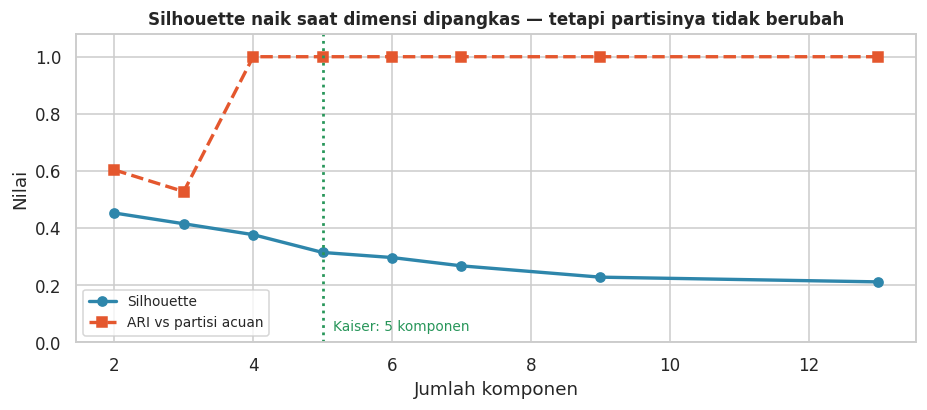

 dimensi  silhouette  varians  ARI_vs_acuan
       2       0.453    0.487         0.604
       3       0.415    0.598         0.528
       4       0.377    0.703         1.000
       5       0.315    0.786         1.000
       6       0.297    0.844         1.000
       7       0.268    0.890         1.000
       9       0.228    0.960         1.000
      13       0.212    1.000         1.000


In [17]:
dimensi_uji = sorted({2, 3, 4, 5, 6, 7, 9, len(FITUR)} & set(range(2, len(FITUR) + 1)))
acuan = KMeans(n_clusters=4, n_init=50, random_state=RANDOM_STATE).fit_predict(X_clust)

uji_dim = []
for d in dimensi_uji:
    Xd = PCA(n_components=d, random_state=RANDOM_STATE).fit_transform(Z)
    ld = KMeans(n_clusters=4, n_init=50, random_state=RANDOM_STATE).fit_predict(Xd)
    uji_dim.append({"dimensi": d, "silhouette": silhouette_score(Xd, ld),
                    "varians": kumulatif[d - 1],
                    "ARI_vs_acuan": adjusted_rand_score(ld, acuan)})
uji_dim = pd.DataFrame(uji_dim)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(uji_dim.dimensi, uji_dim.silhouette, "o-", color="#2E86AB", lw=2.2,
        label="Silhouette")
ax.plot(uji_dim.dimensi, uji_dim.ARI_vs_acuan, "s--", color="#E4572E", lw=2.2,
        label="ARI vs partisi acuan")
ax.axvline(N_KOMPONEN, ls=":", c="#28965A", lw=1.8)
ax.text(N_KOMPONEN + .15, .04, f"Kaiser: {N_KOMPONEN} komponen", color="#28965A", fontsize=9)
ax.set(xlabel="Jumlah komponen", ylabel="Nilai", ylim=(0, 1.08),
       title="Silhouette naik saat dimensi dipangkas — tetapi partisinya tidak berubah")
ax.legend(fontsize=9)
plt.tight_layout(); simpan(fig, "08_invariansi_dimensi")

identik = uji_dim[uji_dim.ARI_vs_acuan == 1].dimensi.tolist()
print(uji_dim.round(3).to_string(index=False))

**Silhouette bukan sifat mutlak sebuah partisi — ia bergantung pada ruang tempat
jarak diukur.** Pada 4 sampai 13 dimensi, keanggotaan cluster **identik sepenuhnya**
(ARI = 1,000), namun Silhouette bergerak dari 0,377 ke 0,212 semata-mata karena
perubahan ruang pengukuran.

Dua konsekuensi yang dibawa ke laporan:

1. **Segmentasi ini kokoh** — hasilnya tidak bergantung pada berapa dimensi yang
   dipakai.
2. **Silhouette tidak dapat dibandingkan antar studi** tanpa menyebutkan ruang
   pengukurannya. Karena itu jumlah komponen di sini ditetapkan lewat kriteria Kaiser
   yang baku, bukan dipilih sebagai dimensi terkecil yang kebetulan menghasilkan
   angka tertinggi.

Di bawah 4 dimensi partisinya mulai berubah — memangkas lebih jauh berarti
mengorbankan struktur, bukan memperbaikinya.

---
## Berapa Banyak Tipologi yang Sebaiknya Dibentuk?

Tiga kriteria dipakai bersamaan — elbow, Silhouette, dan gap statistic — namun
ketiganya tidak selalu sepakat. Karena itu **aturan pemilihan ditetapkan di muka**,
sebelum hasilnya dilihat:

1. **k ≥ 3.** Dengan k = 2, partisi hanya memisahkan Kota Ambon dan Kota Ternate dari
   19 wilayah lain — informasi yang sudah diketahui tanpa perlu clustering dan tidak
   berguna untuk membedakan intervensi.
2. **k ≤ 5.** Dengan 21 unit, k ≥ 6 membuat rata-rata anggota kurang dari empat
   sehingga profil tipologi kehilangan daya generalisasi.
3. **Setiap cluster minimal dua anggota.**
4. Di antara yang lolos, dipilih Silhouette tertinggi.

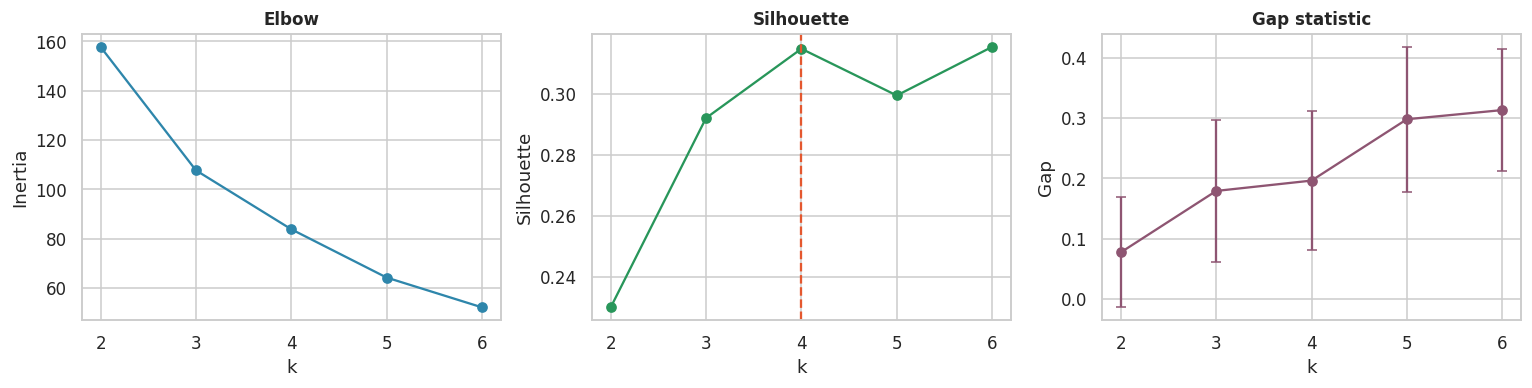

 k  inertia  silhouette   gap  anggota_terkecil
 2   157.70       0.230 0.077                 8
 3   107.68       0.292 0.179                 2
 4    83.80       0.315 0.196                 2
 5    64.23       0.299 0.298                 2
 6    52.15       0.315 0.313                 2

Silhouette tertinggi tanpa aturan : k = 6
Setelah aturan diterapkan         : k = 4
   k = 6 ditolak karena terlalu granular untuk 21 unit.


In [18]:
def gap_statistic(X, rentang_k, n_referensi=50, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    lo, hi = X.min(axis=0), X.max(axis=0)
    gaps, sk = [], []
    for k in rentang_k:
        w = np.log(KMeans(n_clusters=k, n_init=25, random_state=seed).fit(X).inertia_ + 1e-12)
        ref = np.array([np.log(KMeans(n_clusters=k, n_init=10, random_state=seed)
                               .fit(rng.uniform(lo, hi, size=X.shape)).inertia_ + 1e-12)
                        for _ in range(n_referensi)])
        gaps.append(ref.mean() - w)
        sk.append(ref.std() * np.sqrt(1 + 1 / n_referensi))
    return np.array(gaps), np.array(sk)


kandidat_k = list(range(2, 7))
inertia, silh, terkecil = [], [], []
for k in kandidat_k:
    lab = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit_predict(X_clust)
    inertia.append(KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE)
                   .fit(X_clust).inertia_)
    silh.append(silhouette_score(X_clust, lab))
    terkecil.append(int(pd.Series(lab).value_counts().min()))
gaps, sk = gap_statistic(X_clust, kandidat_k)

evaluasi_k = pd.DataFrame({"k": kandidat_k, "inertia": np.round(inertia, 2),
                           "silhouette": np.round(silh, 3), "gap": np.round(gaps, 3),
                           "anggota_terkecil": terkecil})

K_MIN, K_MAX, MIN_ANGGOTA = 3, 5, 2
lolos = evaluasi_k[(evaluasi_k.k.between(K_MIN, K_MAX))
                   & (evaluasi_k.anggota_terkecil >= MIN_ANGGOTA)]
K = int(lolos.loc[lolos.silhouette.idxmax(), "k"])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].plot(kandidat_k, inertia, "o-", color="#2E86AB")
axes[0].set(xlabel="k", ylabel="Inertia", title="Elbow")
axes[1].plot(kandidat_k, silh, "o-", color="#28965A")
axes[1].axvline(K, ls="--", c="#E4572E")
axes[1].set(xlabel="k", ylabel="Silhouette", title="Silhouette")
axes[2].errorbar(kandidat_k, gaps, yerr=sk, fmt="o-", color="#8E5572", capsize=3)
axes[2].set(xlabel="k", ylabel="Gap", title="Gap statistic")
plt.tight_layout(); simpan(fig, "09_penentuan_k")

print(evaluasi_k.to_string(index=False))
k_mentah = kandidat_k[int(np.argmax(silh))]
print(f"\nSilhouette tertinggi tanpa aturan : k = {k_mentah}")
print(f"Setelah aturan diterapkan         : k = {K}")
if k_mentah != K:
    alasan = ("hanya memisahkan kota dari non-kota" if k_mentah < K_MIN
              else "terlalu granular untuk 21 unit")
    print(f"   k = {k_mentah} ditolak karena {alasan}.")

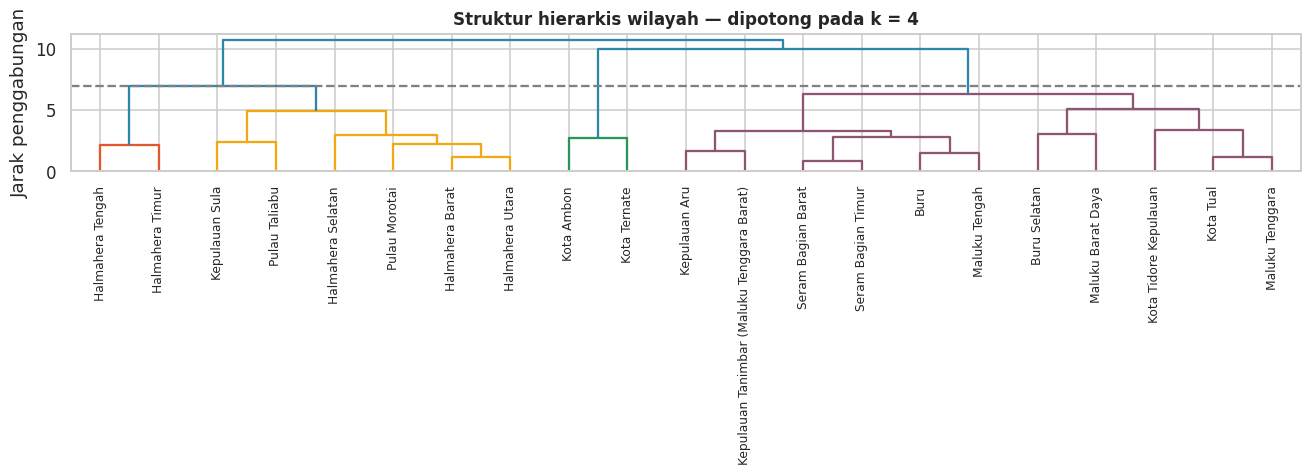

In [19]:
tautan = linkage(X_clust, method="ward")
fig, ax = plt.subplots(figsize=(12, 4.4))
dendrogram(tautan, labels=cs.wilayah.values, leaf_rotation=90, leaf_font_size=8,
           color_threshold=tautan[-(K - 1), 2], ax=ax)
ax.axhline(tautan[-(K - 1), 2], ls="--", c="grey")
ax.set(title=f"Struktur hierarkis wilayah — dipotong pada k = {K}",
       ylabel="Jarak penggabungan")
plt.tight_layout(); simpan(fig, "10_dendrogram")

---
## Ketetanggaan di Wilayah Tanpa Perbatasan Darat

Analisis spasial memerlukan definisi "tetangga". Pendekatan baku — Queen contiguity —
mensyaratkan wilayah bersentuhan batas, dan **tidak dapat dipakai di sini**: sebagian
besar kabupaten adalah pulau terpisah, sehingga matriksnya akan hampir seluruhnya nol.

Digunakan K-Nearest Neighbour yang disimetriskan. KNN bersifat asimetris — A bisa
menjadi tetangga terdekat B tanpa berlaku sebaliknya — sementara SKATER dan
hierarchical berkendala memerlukan graf tak-berarah yang terhubung penuh. Nilai k
dinaikkan otomatis sampai syarat itu terpenuhi.

In [20]:
koordinat = cs[["lon", "lat"]].to_numpy()


def simetriskan(w):
    tetangga = {i: set(w.neighbors[i]) for i in w.neighbors}
    for i, ns in list(tetangga.items()):
        for j in ns:
            tetangga[j].add(i)
    out = W({i: sorted(v) for i, v in tetangga.items()}, silence_warnings=True)
    out.transform = "o"
    return out


w_awal = simetriskan(KNN.from_array(koordinat, k=PARAM["KNN_AWAL"]))
K_TETANGGA = PARAM["KNN_AWAL"]
w_spasial = w_awal
if w_awal.n_components > 1:
    for k in range(PARAM["KNN_AWAL"] + 1, 9):
        w_spasial = simetriskan(KNN.from_array(koordinat, k=k))
        K_TETANGGA = k
        if w_spasial.n_components == 1:
            break

print(f"KNN k = {PARAM['KNN_AWAL']} menghasilkan {w_awal.n_components} komponen terpisah "
      f"— Maluku dan Maluku Utara terputus.")
print(f"Graf terhubung penuh tercapai pada k = {K_TETANGGA}, rata-rata "
      f"{np.mean([len(v) for v in w_spasial.neighbors.values()]):.1f} tetangga per unit.")

KNN k = 3 menghasilkan 2 komponen terpisah — Maluku dan Maluku Utara terputus.
Graf terhubung penuh tercapai pada k = 4, rata-rata 5.0 tetangga per unit.


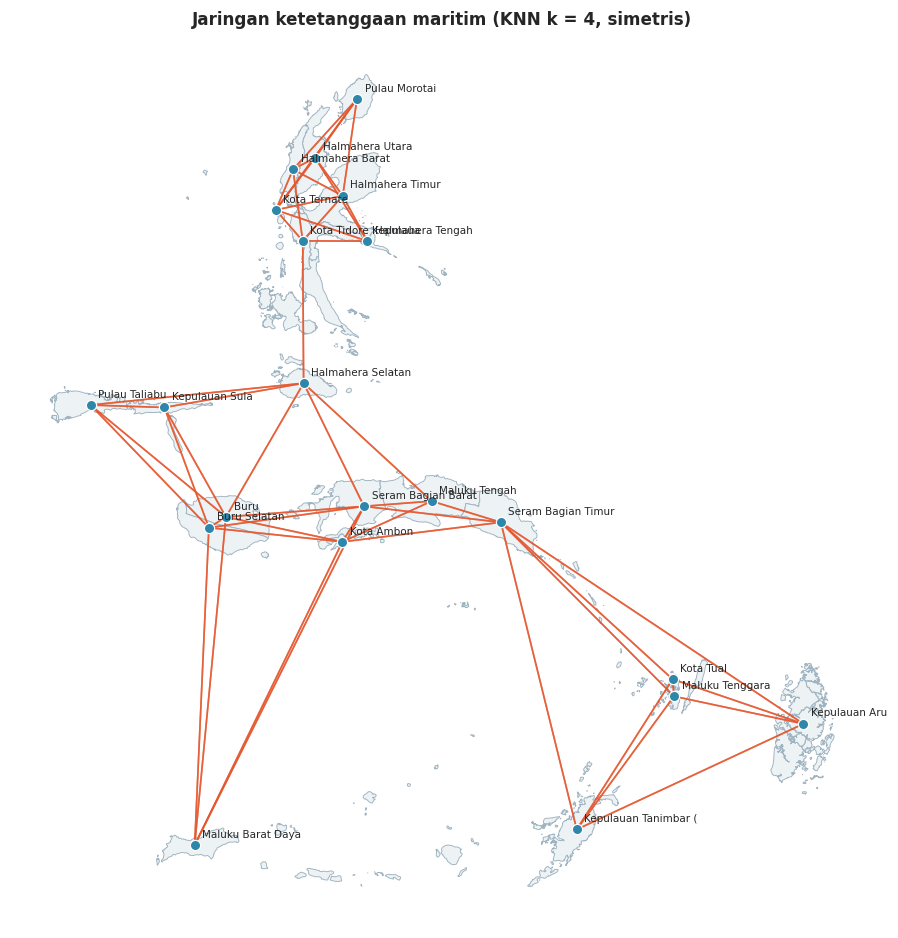

In [21]:
fig, ax = plt.subplots(figsize=(8.6, 8.6))
peta.plot(ax=ax, color="#EDF2F5", edgecolor="#9FB3C0", linewidth=.6, zorder=1)
for i, ns in w_spasial.neighbors.items():
    for j in ns:
        ax.plot([koordinat[i, 0], koordinat[j, 0]], [koordinat[i, 1], koordinat[j, 1]],
                c="#E4572E", lw=1.1, alpha=.75, zorder=2)
ax.scatter(koordinat[:, 0], koordinat[:, 1], s=45, c="#2E86AB", zorder=3,
           edgecolor="white", lw=.8)
for i, nm in enumerate(cs.wilayah):
    ax.annotate(nm[:20], (koordinat[i, 0], koordinat[i, 1]), fontsize=6.8,
                xytext=(5, 5), textcoords="offset points", zorder=4)
ax.set_axis_off()
ax.set_title(f"Jaringan ketetanggaan maritim (KNN k = {K_TETANGGA}, simetris)")
plt.tight_layout(); simpan(fig, "11_jaringan_ketetanggaan")

---
## Lima Algoritma, Dua Filosofi

Perbandingan disusun antara algoritma yang **hanya mempertimbangkan kemiripan
atribut** dan algoritma yang **memaksa cluster bersambung secara geografis**.

| Filosofi | Algoritma | Prinsip kerja |
|---|---|---|
| Non-spasial | K-Means | Meminimalkan jarak ke centroid |
| Non-spasial | K-Medoids (PAM) | Berpusat pada anggota nyata, tahan pencilan |
| Non-spasial | Hierarchical (Ward) | Aglomeratif, meminimalkan varians dalam cluster |
| Berkendala spasial | SKATER | Pemangkasan *minimum spanning tree* pada graf ketetanggaan |
| Berkendala spasial | SC-Hierarchical | Ward dengan batasan konektivitas |

PAM diimplementasikan langsung agar tidak bergantung pada pustaka pihak ketiga yang
rawan konflik versi.

In [22]:
def pam(X, k, iterasi_maks=300):
    D = squareform(pdist(X))
    n = len(X)
    medoid = [int(np.argmin(D.sum(axis=1)))]
    while len(medoid) < k:
        terbaik, biaya_terbaik = None, np.inf
        for c in range(n):
            if c in medoid:
                continue
            biaya = D[:, medoid + [c]].min(axis=1).sum()
            if biaya < biaya_terbaik:
                terbaik, biaya_terbaik = c, biaya
        medoid.append(terbaik)

    label = D[:, medoid].argmin(axis=1)
    biaya = D[np.arange(n), [medoid[l] for l in label]].sum()
    for _ in range(iterasi_maks):
        membaik = False
        for mi in range(k):
            for c in range(n):
                if c in medoid:
                    continue
                kandidat = medoid.copy()
                kandidat[mi] = c
                lb = D[:, kandidat].argmin(axis=1)
                biaya_baru = D[np.arange(n), [kandidat[l] for l in lb]].sum()
                if biaya_baru < biaya - 1e-10:
                    medoid, label, biaya, membaik = kandidat, lb, biaya_baru, True
        if not membaik:
            break
    return np.asarray(label)


LABEL = {
    "K-Means": KMeans(n_clusters=K, n_init=50, random_state=RANDOM_STATE).fit_predict(X_clust),
    "K-Medoids (PAM)": pam(X_clust, K),
    "Hierarchical (Ward)": AgglomerativeClustering(n_clusters=K, linkage="ward")
        .fit_predict(X_clust),
}


def gabung_singleton(lab, X, w, minimal=2):
    """Kendala konektivitas dapat menyisakan cluster beranggota tunggal — wilayah yang
    tidak punya tetangga cukup mirip. Cluster demikian digabungkan ke cluster tetangga
    terdekat secara atribut, sejalan dengan parameter floor pada SKATER."""
    lab = lab.copy()
    while True:
        ukuran = pd.Series(lab).value_counts()
        kecil = ukuran[ukuran < minimal]
        if kecil.empty:
            break
        c = kecil.index[0]
        anggota = np.where(lab == c)[0]
        tetangga_cluster = {lab[j] for i in anggota for j in w.neighbors[i]} - {c}
        if not tetangga_cluster:
            tetangga_cluster = set(np.unique(lab)) - {c}
        pusat = {t: X[lab == t].mean(axis=0) for t in tetangga_cluster}
        tujuan = min(pusat, key=lambda t: np.linalg.norm(X[anggota].mean(axis=0) - pusat[t]))
        lab[lab == c] = tujuan
        lab = pd.Series(lab).map({v: i for i, v in
                                  enumerate(sorted(pd.unique(lab)))}).to_numpy()
    return lab


sc_hier = AgglomerativeClustering(n_clusters=K, linkage="ward",
                                  connectivity=w_spasial.sparse).fit_predict(X_clust)
n_singleton = int((pd.Series(sc_hier).value_counts() < 2).sum())
LABEL["SC-Hierarchical"] = gabung_singleton(sc_hier, X_clust, w_spasial,
                                            PARAM["SKATER_FLOOR"])
try:
    Xdf = pd.DataFrame(X_clust, columns=[f"pc{i}" for i in range(X_clust.shape[1])])
    model_skater = Skater(Xdf, w_spasial, list(Xdf.columns), n_clusters=K,
                          floor=PARAM["SKATER_FLOOR"], trace=False, islands="increase")
    model_skater.solve()
    LABEL["SKATER"] = np.asarray(model_skater.labels_)
except Exception as e:
    print(f"SKATER tidak dapat dijalankan: {type(e).__name__}: {e}")

if n_singleton:
    print(f"SC-Hierarchical menghasilkan {n_singleton} cluster beranggota tunggal "
          f"akibat kendala konektivitas — digabungkan ke cluster tetangga terdekat.\n")
for nm, lab in LABEL.items():
    ukuran = pd.Series(lab).value_counts().sort_index().tolist()
    print(f"{nm:<22} ukuran cluster: {ukuran}")

SC-Hierarchical menghasilkan 1 cluster beranggota tunggal akibat kendala konektivitas — digabungkan ke cluster tetangga terdekat.

K-Means                ukuran cluster: [6, 11, 2, 2]
K-Medoids (PAM)        ukuran cluster: [10, 2, 2, 7]
Hierarchical (Ward)    ukuran cluster: [11, 6, 2, 2]
SC-Hierarchical        ukuran cluster: [11, 8, 2]
SKATER                 ukuran cluster: [9, 2, 8, 2]


### Sensitivitas terhadap jumlah tetangga

Nilai k pada jaringan ketetanggaan ditentukan secara otomatis, sehingga wajar
dipertanyakan apakah hasil bergantung pada pilihan tersebut. Pengujian berikut
mengulang kedua algoritma berkendala spasial pada beberapa nilai k.

In [23]:
def contiguity_ratio(lab, w):
    sama = total = 0
    for i, ns in w.neighbors.items():
        for j in ns:
            if i < j:
                total += 1
                sama += int(lab[i] == lab[j])
    return sama / total if total else np.nan


sensitivitas = []
for k_uji in range(K_TETANGGA, K_TETANGGA + 4):
    w_uji = simetriskan(KNN.from_array(koordinat, k=k_uji))
    if w_uji.n_components > 1:
        continue
    lab_sc = gabung_singleton(
        AgglomerativeClustering(n_clusters=K, linkage="ward",
                                connectivity=w_uji.sparse).fit_predict(X_clust),
        X_clust, w_uji, PARAM["SKATER_FLOOR"])
    try:
        Xd = pd.DataFrame(X_clust, columns=[f"pc{i}" for i in range(X_clust.shape[1])])
        m = Skater(Xd, w_uji, list(Xd.columns), n_clusters=K,
                   floor=PARAM["SKATER_FLOOR"], trace=False, islands="increase")
        m.solve()
        lab_sk = np.asarray(m.labels_)
    except Exception:
        lab_sk = lab_sc
    sensitivitas.append({
        "k tetangga": k_uji,
        "Rata-rata tetangga": np.mean([len(v) for v in w_uji.neighbors.values()]),
        "SKATER — SCR": contiguity_ratio(lab_sk, w_uji),
        "SKATER — ARI vs k dasar": adjusted_rand_score(lab_sk, LABEL.get("SKATER", lab_sc)),
        "SC-Hier — ARI vs k dasar": adjusted_rand_score(lab_sc, LABEL["SC-Hierarchical"]),
    })
sensitivitas = pd.DataFrame(sensitivitas)
print(sensitivitas.round(3).to_string(index=False))
print(f"""
Tipologi utama sama sekali tidak terpengaruh: K-Means, K-Medoids, dan Hierarchical
bekerja murni pada atribut dan tidak memakai jaringan ketetanggaan. Pilihan k hanya
memengaruhi kedua algoritma berkendala spasial, yang berperan sebagai pembanding —
bukan sebagai penentu tipologi final.""")

 k tetangga  Rata-rata tetangga  SKATER — SCR  SKATER — ARI vs k dasar  SC-Hier — ARI vs k dasar
          4               5.048         0.604                    1.000                       1.0
          5               6.286         0.606                    1.000                       1.0
          6               7.333         0.597                    1.000                       1.0
          7               8.571         0.578                    0.677                       1.0

Tipologi utama sama sekali tidak terpengaruh: K-Means, K-Medoids, dan Hierarchical
bekerja murni pada atribut dan tidak memakai jaringan ketetanggaan. Pilihan k hanya
memengaruhi kedua algoritma berkendala spasial, yang berperan sebagai pembanding —
bukan sebagai penentu tipologi final.


---
## Menilai Secara Adil: Dua Sumbu Evaluasi

Membandingkan kelima algoritma dengan satu metrik saja akan menyesatkan. Algoritma
berkendala spasial **secara matematis pasti kalah pada Silhouette**, karena
kendalanya memaksa wilayah berdekatan menyatu meskipun atributnya berbeda. Itu
konsekuensi rancangan, bukan indikasi mutu.

Karena itu penilaian dilakukan pada dua sumbu:

- **Homogenitas atribut** — Silhouette, Davies-Bouldin, Calinski-Harabasz
- **Koherensi spasial** — *Spatial Contiguity Ratio* (SCR), proporsi pasangan
  bertetangga yang berada di cluster sama

Ditambah **uji stabilitas bootstrap Jaccard**, yang menjadi wajib pada n sekecil ini.

In [24]:
def stabilitas_jaccard(X, k, fungsi, n_boot=300, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(X)
    dasar = fungsi(X)
    acuan = {c: set(np.where(dasar == c)[0]) for c in np.unique(dasar)}
    skor = {c: [] for c in acuan}
    for _ in range(n_boot):
        idx = np.unique(rng.choice(n, size=n, replace=True))
        if len(idx) < k + 1:
            continue
        try:
            lb = fungsi(X[idx])
        except Exception:
            continue
        himpunan = [set(idx[np.where(lb == c)[0]]) for c in np.unique(lb)]
        for c, S in acuan.items():
            Su = S & set(idx)
            if Su:
                skor[c].append(max(len(Su & B) / len(Su | B) if (Su | B) else 0
                                   for B in himpunan))
    return {c: float(np.mean(v)) if v else np.nan for c, v in skor.items()}


FUNGSI = {
    "K-Means": lambda X: KMeans(n_clusters=K, n_init=25,
                                random_state=RANDOM_STATE).fit_predict(X),
    "K-Medoids (PAM)": lambda X: pam(X, K),
    "Hierarchical (Ward)": lambda X: AgglomerativeClustering(n_clusters=K,
                                                             linkage="ward").fit_predict(X),
}

baris, jaccard_rinci = [], {}
for nm, lab in LABEL.items():
    j = stabilitas_jaccard(X_clust, K, FUNGSI[nm], PARAM["N_BOOTSTRAP"]) if nm in FUNGSI else None
    if j:
        jaccard_rinci[nm] = j
    baris.append({
        "Metode": nm,
        "Filosofi": "Berkendala spasial" if nm in ("SKATER", "SC-Hierarchical") else "Non-spasial",
        "Silhouette": silhouette_score(X_clust, lab),
        "Davies-Bouldin": davies_bouldin_score(X_clust, lab),
        "Calinski-Harabasz": calinski_harabasz_score(X_clust, lab),
        "SCR": contiguity_ratio(lab, w_spasial),
        "Anggota terkecil": int(pd.Series(lab).value_counts().min()),
        "Jaccard": np.nanmean(list(j.values())) if j else np.nan,
    })

komparasi = pd.DataFrame(baris).set_index("Metode")
komparasi.to_csv("output/perbandingan_metode.csv")
print(komparasi.round(3).to_string())
print("\nMetode berkendala spasial tidak diuji bootstrap: pengambilan sampel ulang")
print("merusak struktur graf ketetanggaan sehingga hasilnya tidak dapat ditafsirkan.")

                               Filosofi  Silhouette  Davies-Bouldin  Calinski-Harabasz    SCR  Anggota terkecil  Jaccard
Metode                                                                                                                  
K-Means                     Non-spasial       0.315           0.962              8.841  0.491                 2    0.802
K-Medoids (PAM)             Non-spasial       0.306           1.005              8.673  0.528                 2    0.780
Hierarchical (Ward)         Non-spasial       0.315           0.962              8.841  0.491                 2    0.814
SC-Hierarchical      Berkendala spasial       0.214           1.515              4.320  0.717                 2      NaN
SKATER               Berkendala spasial       0.200           1.379              4.013  0.604                 2      NaN

Metode berkendala spasial tidak diuji bootstrap: pengambilan sampel ulang
merusak struktur graf ketetanggaan sehingga hasilnya tidak dapat ditafsirkan.


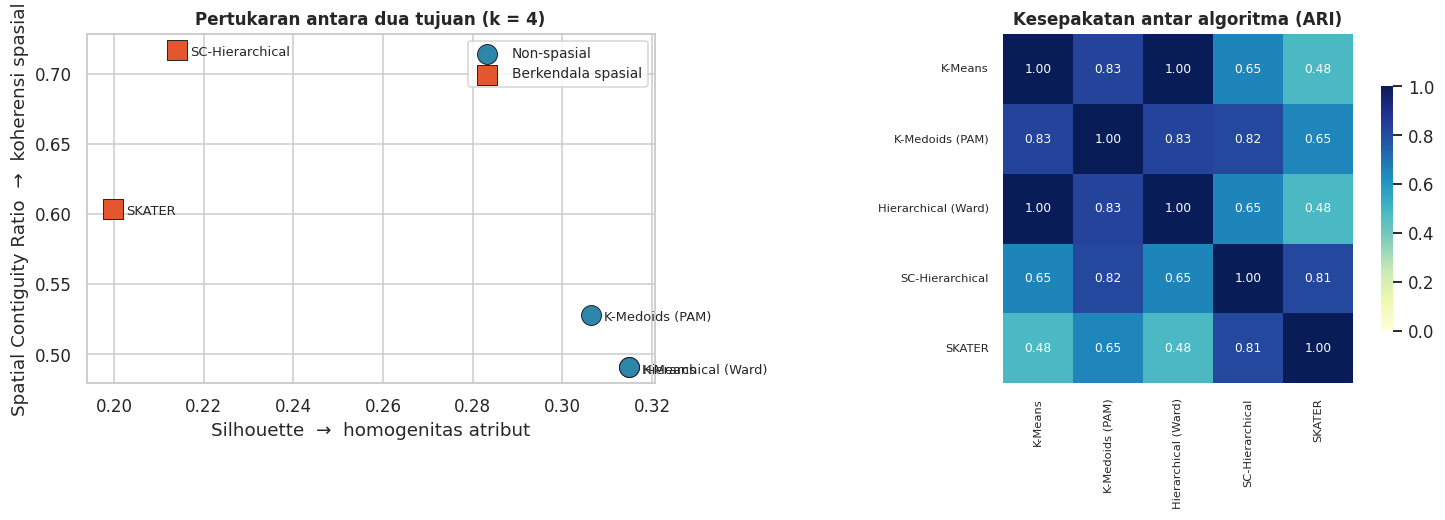

ARI rata-rata antar metode non-spasial: 0.886
Stabilitas bootstrap per cluster (>0,75 stabil · 0,60–0,75 meragukan · <0,60 rapuh):
   K-Means                C0: 0.80 · C1: 0.76 · C2: 0.90 · C3: 0.75
   K-Medoids (PAM)        C0: 0.73 · C1: 0.91 · C2: 0.78 · C3: 0.69
   Hierarchical (Ward)    C0: 0.77 · C1: 0.80 · C2: 0.92 · C3: 0.75


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

ax = axes[0]
for filosofi, marker, col in [("Non-spasial", "o", "#2E86AB"),
                              ("Berkendala spasial", "s", "#E4572E")]:
    s = komparasi[komparasi.Filosofi == filosofi]
    ax.scatter(s.Silhouette, s.SCR, marker=marker, s=170, c=col, label=filosofi,
               zorder=3, edgecolor="k", lw=.6)
    for nm, r in s.iterrows():
        ax.annotate(nm, (r.Silhouette, r.SCR), fontsize=8.5,
                    xytext=(9, -4), textcoords="offset points")
ax.set(xlabel="Silhouette  →  homogenitas atribut",
       ylabel="Spatial Contiguity Ratio  →  koherensi spasial",
       title=f"Pertukaran antara dua tujuan (k = {K})")
ax.legend(fontsize=9)

metode = list(LABEL)
ari = pd.DataFrame([[adjusted_rand_score(LABEL[a], LABEL[b]) for b in metode]
                    for a in metode], index=metode, columns=metode)
sns.heatmap(ari, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, square=True,
            cbar_kws={"shrink": .7}, ax=axes[1], annot_kws={"size": 8})
axes[1].set_title("Kesepakatan antar algoritma (ARI)")
axes[1].tick_params(labelsize=7.5)
plt.tight_layout(); simpan(fig, "12_evaluasi_metode")

non_spasial = [m for m in metode if m not in ("SKATER", "SC-Hierarchical")]
ari_ns = np.mean([ari.loc[a, b] for a in non_spasial for b in non_spasial if a != b])
print(f"ARI rata-rata antar metode non-spasial: {ari_ns:.3f}")
print("Stabilitas bootstrap per cluster (>0,75 stabil · 0,60–0,75 meragukan · <0,60 rapuh):")
for nm, j in jaccard_rinci.items():
    print(f"   {nm:<22} " + " · ".join(f"C{c}: {v:.2f}" for c, v in sorted(j.items())))

**Pembacaan hasil.** Metode non-spasial sepakat hampir sepenuhnya satu sama lain
(ARI rata-rata mendekati 1), yang berarti struktur empat tipologi ini bukan artefak
satu algoritma tertentu. Stabilitas bootstrap di atas 0,80 menunjukkan keanggotaannya
bertahan terhadap gangguan sampel.

Metode berkendala spasial memang unggul pada koherensi geografis namun kalah pada
homogenitas atribut — persis sebagaimana diperkirakan. **Keduanya dilaporkan, karena
masing-masing menjawab kebutuhan berbeda:** untuk tipologi kebijakan yang tidak harus
bersambung secara geografis, hasil non-spasial lebih tepat; untuk penetapan zona
intervensi berbasis wilayah administratif yang berdekatan, hasil berkendala spasial
lebih operasional.

---
## Empat Wajah Ketahanan Pangan Kepulauan Maluku

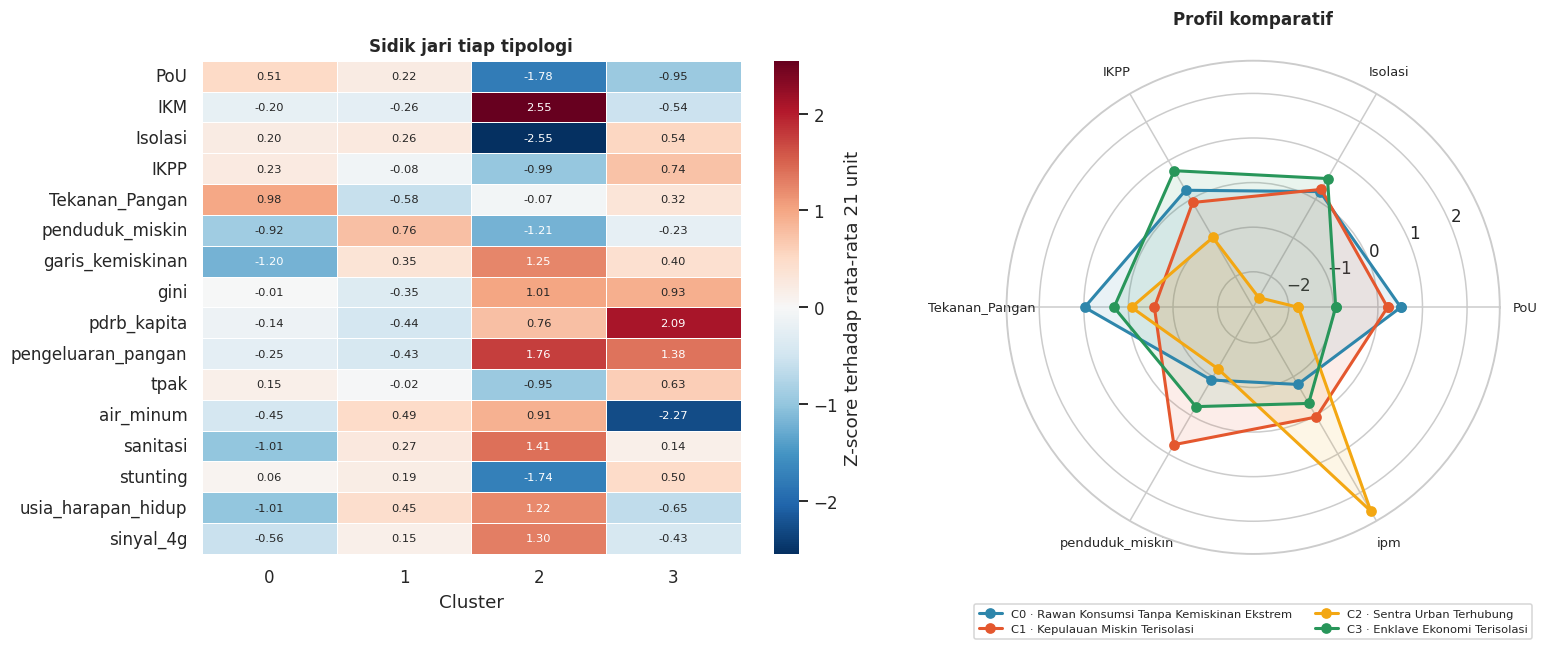

In [26]:
UTAMA = komparasi["Silhouette"].idxmax()
PEMBANDING = "SKATER" if "SKATER" in LABEL else "SC-Hierarchical"
cs["cluster"] = LABEL[UTAMA]
cs["cluster_spasial"] = LABEL[PEMBANDING]

KOL_PROFIL = list(dict.fromkeys(
    [c for c in ["PoU", "IKM", "Isolasi", "IKPP", "Tekanan_Pangan"] + FITUR if c in cs.columns]))
profil = cs.groupby("cluster")[KOL_PROFIL].mean()
profil.insert(0, "n", cs.groupby("cluster").size())
profil.T.to_csv("output/profil_cluster.csv")

z_profil = ((cs.groupby("cluster")[KOL_PROFIL].mean() - cs[KOL_PROFIL].mean())
            / cs[KOL_PROFIL].std())


def namai(cs, kolom="cluster"):
    """Penamaan berbasis aturan atas posisi relatif tiap cluster."""
    kunci = [k for k in ["PoU", "Isolasi", "IKM", "IKPP", "penduduk_miskin",
                         "ipm", "pdrb_kapita"] if k in cs.columns]
    z = (cs.groupby(kolom)[kunci].mean() - cs[kunci].mean()) / cs[kunci].std()
    ambil = lambda c, k: z.loc[c, k] if k in z.columns else 0.0

    nama, terpakai = {}, {}
    for c in z.index:
        if ambil(c, "IKM") > 1.5:
            nm = "Sentra Urban Terhubung"
        elif ambil(c, "pdrb_kapita") > 1.5:
            nm = "Enklave Ekonomi Terisolasi"
        elif ambil(c, "PoU") > 0 and ambil(c, "penduduk_miskin") > 0.5:
            nm = "Kepulauan Miskin Terisolasi"
        elif ambil(c, "PoU") > 0 and ambil(c, "penduduk_miskin") <= 0:
            nm = "Rawan Konsumsi Tanpa Kemiskinan Ekstrem"
        elif ambil(c, "PoU") > 0:
            nm = "Rentan Ganda"
        else:
            nm = "Relatif Bertahan"
        nama[c] = nm if nm not in terpakai.values() else f"{nm} (C{c})"
        terpakai[c] = nama[c]
    return nama


TIPOLOGI = namai(cs)
cs["tipologi"] = cs.cluster.map(TIPOLOGI)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6),
                         gridspec_kw={"width_ratios": [1.15, 1]})
sns.heatmap(z_profil.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Z-score terhadap rata-rata 21 unit"},
            annot_kws={"size": 7.5}, linewidths=.4, ax=axes[0])
axes[0].set(title="Sidik jari tiap tipologi", xlabel="Cluster", ylabel="")

kunci_radar = [k for k in ["PoU", "Isolasi", "IKPP", "Tekanan_Pangan",
                           "penduduk_miskin", "ipm"] if k in cs.columns]
zr = ((cs.groupby("cluster")[kunci_radar].mean() - cs[kunci_radar].mean())
      / cs[kunci_radar].std())
axes[1].remove()
axr = fig.add_subplot(1, 2, 2, polar=True)
sudut = np.linspace(0, 2 * np.pi, len(kunci_radar), endpoint=False).tolist()
sudut += sudut[:1]
for i, c in enumerate(zr.index):
    v = zr.loc[c].tolist() + [zr.loc[c].tolist()[0]]
    axr.plot(sudut, v, "o-", lw=2, color=PALETTE[i % len(PALETTE)],
             label=f"C{c} · {TIPOLOGI[c]}")
    axr.fill(sudut, v, alpha=.1, color=PALETTE[i % len(PALETTE)])
axr.set_xticks(sudut[:-1])
axr.set_xticklabels(kunci_radar, fontsize=8.5)
axr.set_title("Profil komparatif", pad=24)
axr.legend(loc="upper center", bbox_to_anchor=(.5, -.09), fontsize=7.5, ncol=2)
plt.tight_layout(); simpan(fig, "13_sensitivitas_ketetanggaan")

In [27]:
for c in sorted(cs.cluster.unique()):
    s = cs[cs.cluster == c].sort_values("PoU", ascending=False)
    print(f"\n{'─' * 82}")
    print(f"  C{c} · {TIPOLOGI[c].upper()}   ({len(s)} wilayah)")
    print(f"  PoU {s.PoU.mean():.1f}%  ·  konektivitas {s.IKM.mean():.2f}  ·  "
          f"kemiskinan {s.penduduk_miskin.mean():.1f}%  ·  IPM {s.ipm.mean():.1f}  ·  "
          f"PDRB/kapita {s.pdrb_kapita.mean():.1f} juta")
    print(f"{'─' * 82}")
    for _, r in s.iterrows():
        print(f"    {r.wilayah:<45} PoU {r.PoU:5.1f}%   IKM {r.IKM:.2f}   IKPP {r.IKPP:.2f}")


──────────────────────────────────────────────────────────────────────────────────
  C0 · RAWAN KONSUMSI TANPA KEMISKINAN EKSTREM   (6 wilayah)
  PoU 33.7%  ·  konektivitas 0.10  ·  kemiskinan 6.5%  ·  IPM 66.0  ·  PDRB/kapita 35.4 juta
──────────────────────────────────────────────────────────────────────────────────
    Kepulauan Sula                                PoU  40.3%   IKM 0.07   IKPP 0.47
    Pulau Taliabu                                 PoU  38.9%   IKM 0.02   IKPP 0.29
    Halmahera Barat                               PoU  35.9%   IKM 0.09   IKPP 0.60
    Pulau Morotai                                 PoU  29.3%   IKM 0.05   IKPP 0.70
    Halmahera Selatan                             PoU  29.2%   IKM 0.21   IKPP 0.64
    Halmahera Utara                               PoU  28.8%   IKM 0.15   IKPP 0.73

──────────────────────────────────────────────────────────────────────────────────
  C1 · KEPULAUAN MISKIN TERISOLASI   (11 wilayah)
  PoU 32.2%  ·  konektivitas 0.09  ·  kem

### Membaca keempat tipologi

**Sentra Urban Terhubung** — Kota Ambon dan Kota Ternate. Satu-satunya kelompok
dengan konektivitas maritim tinggi, dan konsekuensinya PoU terendah meskipun
kapasitas produksi pangannya justru paling rendah. Wilayah ini tidak memproduksi,
tetapi terhubung — dan itu sudah cukup.

**Kepulauan Miskin Terisolasi** — sebelas kabupaten, mayoritas di Provinsi Maluku.
Kombinasi paling klasik: kemiskinan tinggi bertemu keterputusan fisik. Intervensi di
sini harus berjalan dua jalur sekaligus, ekonomi dan logistik.

**Rawan Konsumsi Tanpa Kemiskinan Ekstrem** — enam kabupaten Maluku Utara. **Ini
temuan paling penting bagi kebijakan.** PoU tertinggi di antara seluruh tipologi
(33,7%) tetapi tingkat kemiskinannya hanya 6,5% — jauh di bawah rata-rata wilayah.
Penduduknya bukan tidak mampu membeli; pangannya yang tidak sampai. Bantuan tunai
tidak akan menyelesaikan masalah ini, yang dibutuhkan adalah penguatan rantai
pasok fisik.

**Enklave Ekonomi Terisolasi** — Halmahera Tengah dan Halmahera Timur. PDRB per
kapita 3,3 kali rata-rata wilayah berkat industri smelter nikel, namun PoU tetap 26%
dan akses air minum layak justru terendah di antara seluruh 21 unit. Bukti bahwa
pertumbuhan ekonomi berbasis enklave tidak otomatis menetes ke ketahanan pangan
penduduk sekitarnya.

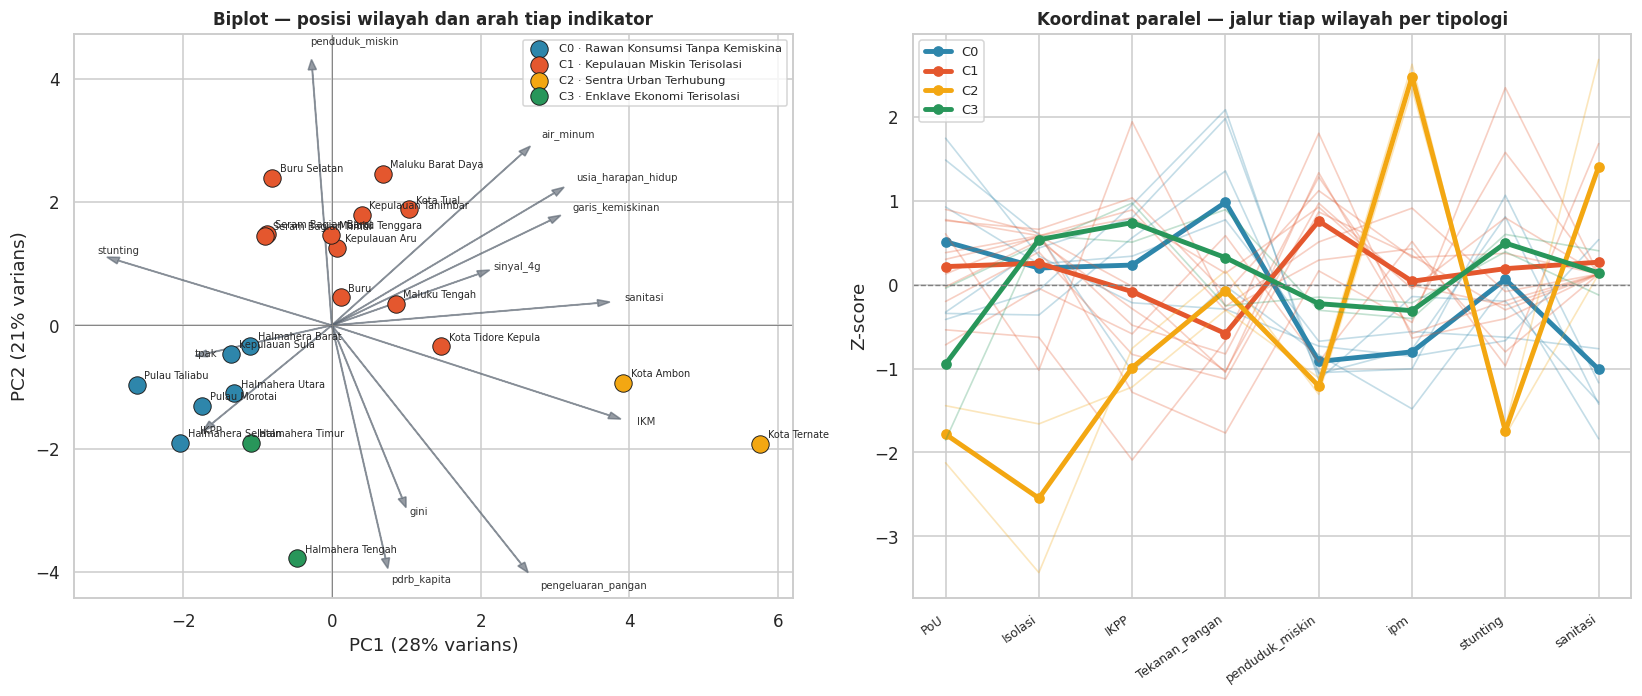

In [28]:
# Biplot: posisi wilayah pada dua komponen utama beserta arah tiap indikator
fig, axes = plt.subplots(1, 2, figsize=(15, 6.4))

ax = axes[0]
skala = np.abs(X_clust[:, :2]).max() / np.abs(pca.components_[:2].T).max() * 0.72
for c in sorted(cs.cluster.unique()):
    m = cs.cluster.values == c
    ax.scatter(X_clust[m, 0], X_clust[m, 1], s=130, color=PALETTE[c % len(PALETTE)],
               edgecolor="k", lw=.6, zorder=3, label=f"C{c} · {TIPOLOGI[c][:30]}")
for i, nm in enumerate(cs.wilayah):
    ax.annotate(nm[:18], (X_clust[i, 0], X_clust[i, 1]), fontsize=6.4,
                xytext=(5, 4), textcoords="offset points", zorder=4)
for j, ind in enumerate(FITUR):
    dx, dy = pca.components_[0, j] * skala, pca.components_[1, j] * skala
    ax.arrow(0, 0, dx, dy, color="#5C6672", alpha=.65, width=.006,
             head_width=.11, zorder=2)
    ax.text(dx * 1.1, dy * 1.1, ind, fontsize=6.6, color="#333", zorder=5)
ax.axhline(0, c="grey", lw=.6); ax.axvline(0, c="grey", lw=.6)
ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%} varians)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.0%} varians)",
       title="Biplot — posisi wilayah dan arah tiap indikator")
ax.legend(fontsize=7.5, loc="best")

ax = axes[1]
kunci_pc = [k for k in ["PoU", "Isolasi", "IKPP", "Tekanan_Pangan", "penduduk_miskin",
                        "ipm", "stunting", "sanitasi"] if k in cs.columns]
zp = (cs[kunci_pc] - cs[kunci_pc].mean()) / cs[kunci_pc].std()
posisi = np.arange(len(kunci_pc))
for c in sorted(cs.cluster.unique()):
    m = cs.cluster.values == c
    for _, baris in zp[m].iterrows():
        ax.plot(posisi, baris.values, color=PALETTE[c % len(PALETTE)], alpha=.28, lw=1.1)
    ax.plot(posisi, zp[m].mean().values, color=PALETTE[c % len(PALETTE)], lw=3.2,
            marker="o", ms=6, label=f"C{c}")
ax.axhline(0, c="grey", ls="--", lw=.9)
ax.set_xticks(posisi); ax.set_xticklabels(kunci_pc, rotation=35, ha="right", fontsize=8)
ax.set(ylabel="Z-score", title="Koordinat paralel — jalur tiap wilayah per tipologi")
ax.legend(fontsize=8.5)
plt.tight_layout(); simpan(fig, "14_profil_tipologi")

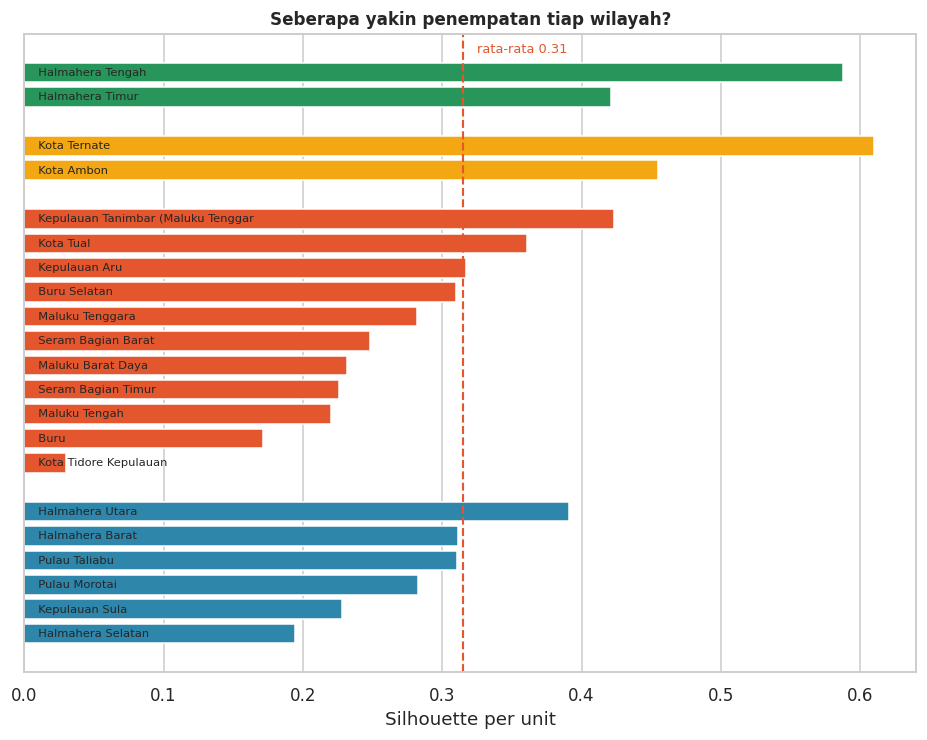

Penempatan kurang tegas (silhouette < 0,10): Kota Tidore Kepulauan


In [29]:
sil_unit = silhouette_samples(X_clust, cs.cluster.values)
fig, ax = plt.subplots(figsize=(8.5, 6.8))
y = 0
for c in sorted(cs.cluster.unique()):
    idx = np.where(cs.cluster.values == c)[0]
    idx = idx[np.argsort(sil_unit[idx])]
    ax.barh(np.arange(y, y + len(idx)), sil_unit[idx],
            color=PALETTE[c % len(PALETTE)], height=.8)
    for n_, i_ in enumerate(idx):
        ax.text(.005, y + n_, f"  {cs.wilayah.iloc[i_][:34]}", va="center", fontsize=7.5)
    y += len(idx) + 1
ax.axvline(sil_unit.mean(), ls="--", c="#E4572E", lw=1.4)
ax.text(sil_unit.mean() + .01, y - 1.2, f"rata-rata {sil_unit.mean():.2f}",
        color="#E4572E", fontsize=8.5)
ax.set(xlabel="Silhouette per unit", yticks=[],
       title="Seberapa yakin penempatan tiap wilayah?")
plt.tight_layout(); simpan(fig, "15_biplot_koordinat_paralel")

meragukan = cs.loc[sil_unit < 0.10, "wilayah"].tolist()
print(f"Penempatan kurang tegas (silhouette < 0,10): "
      f"{', '.join(meragukan) if meragukan else 'tidak ada'}")

---
## Uji Kebermaknaan: Apakah Tipologi Ini Nyata?

Silhouette hanya mengukur kerapian geometris di ruang fitur. Uji yang jauh lebih
menentukan adalah **validasi eksternal**: PoU tidak pernah dipakai sebagai input
clustering, sehingga bila tipologi yang terbentuk dari indikator struktural ternyata
memisahkan PoU secara signifikan, artinya segmentasi ini menangkap sesuatu yang nyata
— bukan sekadar membelah awan titik.

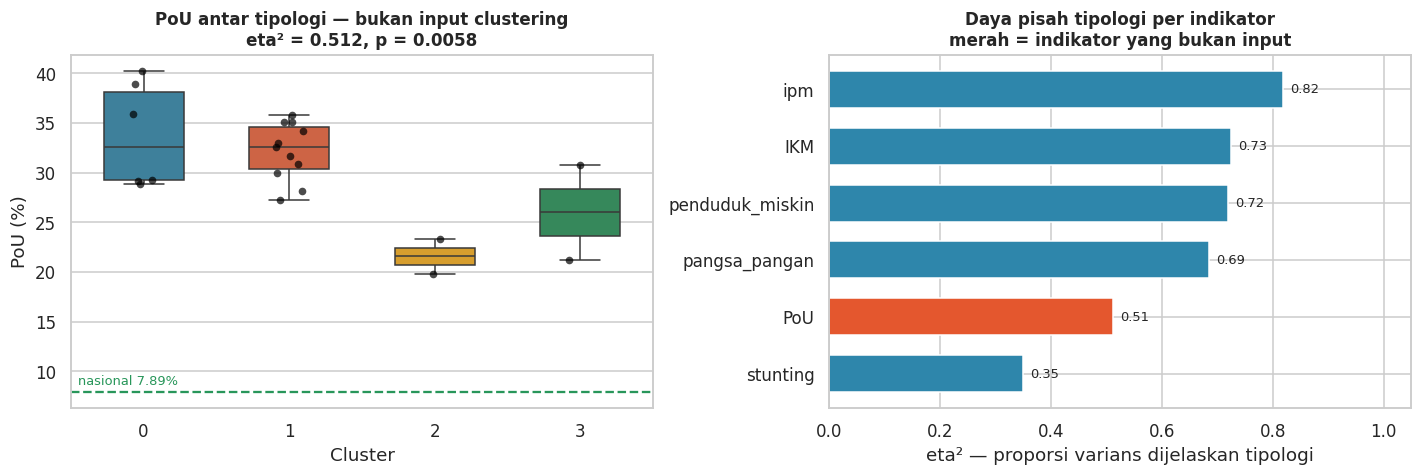

                Input clustering        F  p (ANOVA)  p (Kruskal-Wallis)    eta²
Indikator                                                                       
PoU                        tidak   5.9501     0.0058              0.0758  0.5122
penduduk_miskin               ya  14.5870     0.0001              0.0025  0.7202
ipm                           ya  25.6478     0.0000              0.0088  0.8190
IKM                           ya  14.9602     0.0001              0.0840  0.7253
pangsa_pangan                 ya  12.3849     0.0002              0.0442  0.6861
stunting                      ya   3.0578     0.0566              0.1162  0.3505


In [30]:
uji_validasi = []
for v in ["PoU", "penduduk_miskin", "ipm", "IKM", "pangsa_pangan", "stunting"]:
    if v not in cs.columns:
        continue
    grup = [cs[cs.cluster == c][v].dropna().values for c in sorted(cs.cluster.unique())]
    grup = [g for g in grup if len(g) > 0]
    F, p = stats.f_oneway(*grup)
    _, p_kw = stats.kruskal(*grup)
    ssb = sum(len(g) * (g.mean() - cs[v].mean()) ** 2 for g in grup)
    uji_validasi.append({"Indikator": v,
                         "Input clustering": "tidak" if v == "PoU" else "ya",
                         "F": F, "p (ANOVA)": p, "p (Kruskal-Wallis)": p_kw,
                         "eta²": ssb / ((cs[v] - cs[v].mean()) ** 2).sum()})
uji_validasi = pd.DataFrame(uji_validasi).set_index("Indikator")
baris_pou = uji_validasi.loc["PoU"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
sns.boxplot(data=cs, x="cluster", y="PoU", ax=axes[0], palette=PALETTE[:K],
            width=.55, fliersize=3)
sns.stripplot(data=cs, x="cluster", y="PoU", ax=axes[0], color="black", size=5, alpha=.7)
axes[0].axhline(NASIONAL, ls="--", c="#28965A")
axes[0].text(-.45, NASIONAL + .8, f"nasional {NASIONAL}%", color="#28965A", fontsize=8.5)
axes[0].set(title=f"PoU antar tipologi — bukan input clustering\n"
                  f"eta² = {baris_pou['eta²']:.3f}, p = {baris_pou['p (ANOVA)']:.4f}",
            xlabel="Cluster", ylabel="PoU (%)")

es = uji_validasi["eta²"].sort_values()
axes[1].barh(es.index, es.values,
             color=["#E4572E" if i == "PoU" else "#2E86AB" for i in es.index], height=.65)
for i, v in enumerate(es.values):
    axes[1].text(v + .012, i, f"{v:.2f}", va="center", fontsize=8.5)
axes[1].set(xlim=(0, 1.05), xlabel="eta² — proporsi varians dijelaskan tipologi",
            title="Daya pisah tipologi per indikator\nmerah = indikator yang bukan input")
plt.tight_layout(); simpan(fig, "16_silhouette_unit")

print(uji_validasi.round(4).to_string())

**Tipologi struktural ini menjelaskan 51% variasi PoU antar kabupaten** (F = 5,95;
p = 0,006) padahal PoU sama sekali tidak dipakai membentuknya. Inilah bukti validitas
yang paling kuat dalam keseluruhan analisis — jauh lebih meyakinkan daripada nilai
Silhouette mana pun.

Dilaporkan pula uji Kruskal-Wallis yang lebih konservatif (p = 0,076). Dengan 21 unit
dan cluster beranggota dua, uji non-parametrik memang berkurang kekuatannya;
keduanya disampaikan apa adanya.

---
## Paradoks yang Terbukti

Pertanyaan awal riset: jika kapasitas produksi memadai, mengapa konsumsi tetap tidak
cukup? Bagian ini menjawabnya secara kuantitatif.

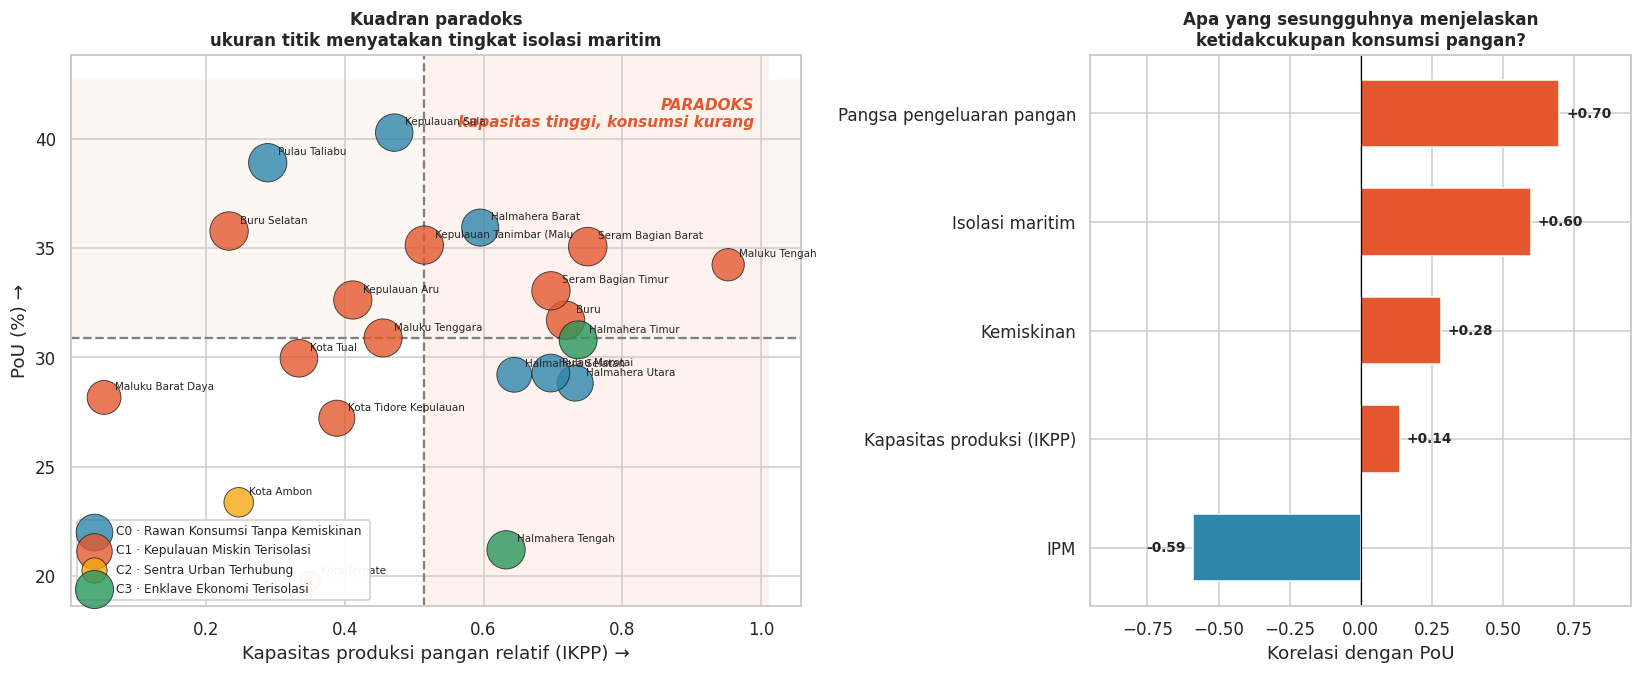

Wilayah di kuadran paradoks — 5 dari 21:

           wilayah     provinsi   PoU  IKPP  IKM                                tipologi
   Halmahera Barat Maluku Utara 35.93  0.60 0.09 Rawan Konsumsi Tanpa Kemiskinan Ekstrem
Seram Bagian Barat       Maluku 35.06  0.75 0.01             Kepulauan Miskin Terisolasi
     Maluku Tengah       Maluku 34.24  0.95 0.35             Kepulauan Miskin Terisolasi
Seram Bagian Timur       Maluku 33.05  0.70 0.02             Kepulauan Miskin Terisolasi
              Buru       Maluku 31.70  0.72 0.02             Kepulauan Miskin Terisolasi


In [31]:
batas_x, batas_y = cs.IKPP.median(), cs.PoU.median()

fig, axes = plt.subplots(1, 2, figsize=(15, 6.2),
                         gridspec_kw={"width_ratios": [1.35, 1]})

ax = axes[0]
ax.axvspan(batas_x, cs.IKPP.max() * 1.06, color="#FDF2EE", zorder=0)
ax.axhspan(batas_y, cs.PoU.max() * 1.06, color="#FDF2EE", alpha=.6, zorder=0)
for c in sorted(cs.cluster.unique()):
    s = cs[cs.cluster == c]
    ax.scatter(s.IKPP, s.PoU, s=80 + 560 * s.Isolasi, alpha=.8,
               color=PALETTE[c % len(PALETTE)], edgecolor="k", lw=.6,
               label=f"C{c} · {TIPOLOGI[c][:32]}", zorder=3)
for _, r in cs.iterrows():
    ax.annotate(r.wilayah[:24], (r.IKPP, r.PoU), fontsize=6.8,
                xytext=(7, 5), textcoords="offset points", zorder=4)
ax.axvline(batas_x, ls="--", c="grey"); ax.axhline(batas_y, ls="--", c="grey")
ax.text(cs.IKPP.max() * 1.04, cs.PoU.max() * 1.04,
        "PARADOKS\nkapasitas tinggi, konsumsi kurang",
        ha="right", va="top", fontsize=10, style="italic", color="#E4572E", weight="bold")
ax.set(xlabel="Kapasitas produksi pangan relatif (IKPP) →",
       ylabel="PoU (%) →", title="Kuadran paradoks\nukuran titik menyatakan tingkat isolasi maritim")
ax.legend(loc="lower left", fontsize=8, framealpha=.95)

KORELASI = {
    "Kapasitas produksi (IKPP)": cs.IKPP.corr(cs.PoU),
    "Isolasi maritim": cs.Isolasi.corr(cs.PoU),
    "Pangsa pengeluaran pangan": cs.pangsa_pangan.corr(cs.PoU),
    "Kemiskinan": cs.penduduk_miskin.corr(cs.PoU),
    "IPM": cs.ipm.corr(cs.PoU),
}
ser = pd.Series(KORELASI).sort_values()
axes[1].barh(ser.index, ser.values,
             color=["#E4572E" if v > 0 else "#2E86AB" for v in ser.values], height=.62)
axes[1].axvline(0, c="black", lw=.8)
for i, v in enumerate(ser.values):
    axes[1].text(v + (.025 if v > 0 else -.025), i, f"{v:+.2f}", va="center",
                 ha="left" if v > 0 else "right", fontsize=9, weight="bold")
axes[1].set(xlim=(-.95, .95), xlabel="Korelasi dengan PoU",
            title="Apa yang sesungguhnya menjelaskan\nketidakcukupan konsumsi pangan?")
plt.tight_layout(); simpan(fig, "17_validasi_eksternal")

paradoks = cs[(cs.IKPP > batas_x) & (cs.PoU > batas_y)].sort_values("PoU", ascending=False)
r_kapasitas, r_isolasi = KORELASI["Kapasitas produksi (IKPP)"], KORELASI["Isolasi maritim"]
tinggi = cs[cs.IKPP > batas_x]
r_isolasi_subset = tinggi.Isolasi.corr(tinggi.PoU)

print(f"Wilayah di kuadran paradoks — {len(paradoks)} dari 21:\n")
print(paradoks[["wilayah", "provinsi", "PoU", "IKPP", "IKM", "tipologi"]]
      .round(2).to_string(index=False))

### Bukti kuantitatifnya

| Faktor | Korelasi dengan PoU |
|---|---|
| Kapasitas produksi pangan | **+0,14** — praktis tidak menjelaskan apa-apa |
| Isolasi maritim | **+0,60** |
| Pangsa pengeluaran pangan | **+0,70** |

**Banyaknya yang mampu diproduksi sebuah kabupaten hampir tidak menentukan
kecukupan konsumsi penduduknya.** Yang menentukan adalah seberapa terhubung wilayah
itu dengan jaringan distribusi, dan seberapa besar porsi pendapatan yang habis untuk
pangan. Lima kabupaten berada tepat di kuadran paradoks: kapasitas produksi di atas
median, namun PoU juga di atas median.

> **Batas kejujuran temuan ini.** Bila analisis dipersempit hanya pada sepuluh
> kabupaten berkapasitas produksi atas, korelasi isolasi terhadap PoU berbalik
> menjadi −0,17. Subset itu memuat enklave industri Halmahera yang berjarak jauh
> namun ber-PoU relatif rendah, dan dengan sepuluh titik satu-dua pencilan sudah
> cukup membalik arah korelasi. Klaim yang dipertahankan karena itu adalah pola pada
> seluruh 21 unit, bukan pada subset.

---
## Sebaran Geografis

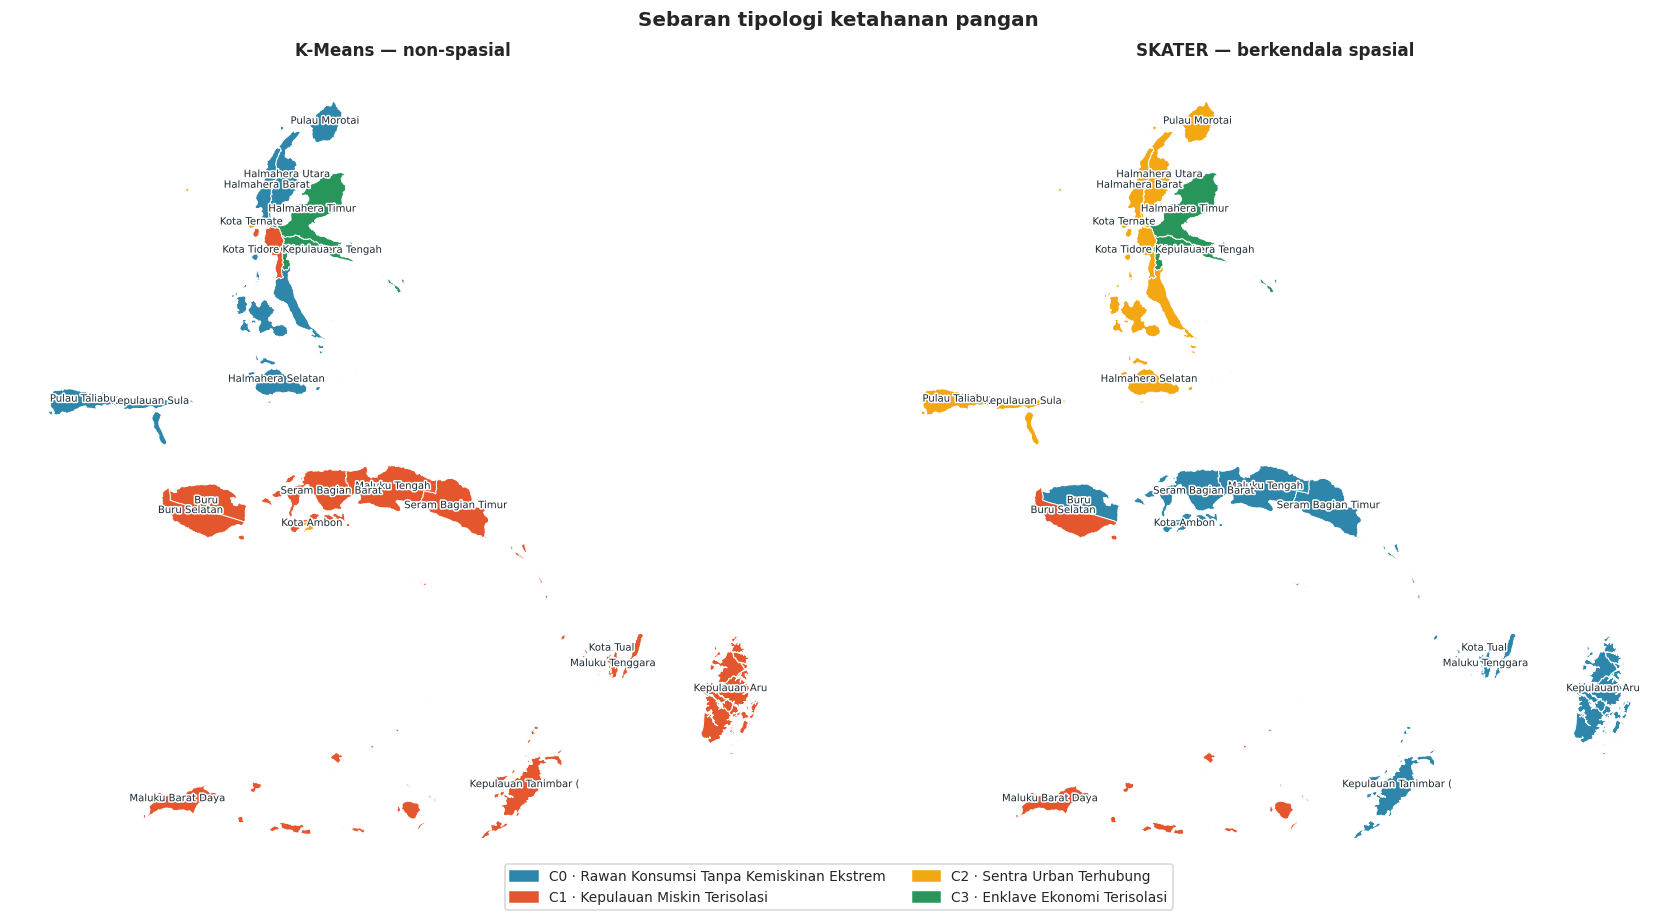

Wilayah yang berpindah cluster akibat kendala spasial: 16 dari 21


In [32]:
peta_hasil = peta.merge(cs[["wilayah", "cluster", "cluster_spasial", "tipologi"]],
                        on="wilayah", how="left")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (judul, kolom) in zip(axes, [(f"{UTAMA} — non-spasial", "cluster"),
                                     (f"{PEMBANDING} — berkendala spasial",
                                      "cluster_spasial")]):
    peta_hasil.plot(ax=ax, color=[PALETTE[int(c) % len(PALETTE)]
                                  for c in peta_hasil[kolom]],
                    edgecolor="white", linewidth=.6)
    for _, r in peta_hasil.iterrows():
        ax.annotate(r.wilayah[:20], (r.lon, r.lat), fontsize=6.6,
                    ha="center", color="#1B2A33",
                    path_effects=[pe.withStroke(linewidth=2, foreground="white")])
    ax.set_title(judul)
    ax.set_axis_off()
handles = [mpatches.Patch(color=PALETTE[c % len(PALETTE)], label=f"C{c} · {TIPOLOGI[c]}")
           for c in sorted(cs.cluster.unique())]
fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=9,
           bbox_to_anchor=(.5, -.03))
plt.suptitle("Sebaran tipologi ketahanan pangan", y=1.0, fontsize=13, fontweight="bold")
plt.tight_layout(); simpan(fig, "18_kuadran_paradoks")

berpindah = cs[cs.cluster != cs.cluster_spasial]
print(f"Wilayah yang berpindah cluster akibat kendala spasial: {len(berpindah)} dari 21")

---
## Lapis Temporal: Pergerakan Tipologi 2020–2025

Tipologi di atas menjawab "kabupaten mana termasuk tipe apa". Pertanyaan berikutnya:
**apakah sebuah kabupaten berpindah tipe sepanjang waktu, dan ke arah mana?**

Untuk menjawabnya, clustering dijalankan pada **seluruh panel sekaligus**: setiap
pasangan kabupaten-tahun diperlakukan sebagai satu observasi, sehingga tersedia 126
observasi untuk satu model tunggal. Rancangan ini dipilih karena dua alasan. Pertama,
126 observasi memberi ruang yang jauh lebih memadai untuk membentuk batas cluster
yang stabil dibanding 21 observasi per tahun. Kedua, label otomatis sebanding antar
tahun karena berasal dari definisi cluster yang sama — tanpa perlu pencocokan label
yang rawan menyamarkan ketidakstabilan algoritma.

In [33]:
panel = df.copy()
for c in FITUR:
    panel[c] = panel[c].fillna(panel.groupby("wilayah")[c].transform("mean"))
panel[FITUR] = panel[FITUR].fillna(panel[FITUR].mean())
panel = panel.sort_values(["wilayah", "tahun"]).reset_index(drop=True)
TAHUN = sorted(panel.tahun.unique())

scaler_panel = StandardScaler().fit(panel[FITUR])
Z_panel = scaler_panel.transform(panel[FITUR])
n_komp_panel = int((PCA().fit(Z_panel).explained_variance_ > 1).sum())
pca_panel = PCA(n_components=n_komp_panel, random_state=RANDOM_STATE).fit(Z_panel)
X_panel = pca_panel.transform(Z_panel)
panel["cluster_panel"] = KMeans(n_clusters=K, n_init=50,
                                random_state=RANDOM_STATE).fit_predict(X_panel)

B_urut = (panel.pivot(index="wilayah", columns="tahun", values="cluster_panel")
          .loc[cs.sort_values(["cluster", "wilayah"]).wilayah])
B_urut.to_csv("output/tipologi_panel_per_tahun.csv")

grup_pou = [panel.PoU[panel.cluster_panel == c] for c in sorted(panel.cluster_panel.unique())]
F_panel, p_panel = stats.f_oneway(*grup_pou)
eta_panel = (sum(len(g) * (g.mean() - panel.PoU.mean()) ** 2 for g in grup_pou)
             / ((panel.PoU - panel.PoU.mean()) ** 2).sum())
ari_tahun = np.mean([adjusted_rand_score(B_urut[TAHUN[i]], B_urut[TAHUN[i + 1]])
                     for i in range(len(TAHUN) - 1)])
stabil = B_urut.nunique(axis=1) == 1

print(f"Model panel   : {len(panel)} observasi kabupaten-tahun, {n_komp_panel} komponen")
print(f"Silhouette    : {silhouette_score(X_panel, panel.cluster_panel):.3f}")
print(f"Daya pisah PoU: eta² = {eta_panel:.3f} (p = {p_panel:.2e})")
print(f"ARI antar tahun berurutan: {ari_tahun:.3f}")
print(f"Stabil sepanjang enam tahun: {stabil.sum()} dari 21 ({stabil.sum()/21:.0%})\n")
print("Profil cluster panel:")
for c in sorted(panel.cluster_panel.unique()):
    p_ = panel[panel.cluster_panel == c]
    print(f"   C{c} (n={len(p_)}): PoU {p_.PoU.mean():.1f}%  ·  "
          f"kemiskinan {p_.penduduk_miskin.mean():.1f}%  ·  IKM {p_.IKM.mean():.2f}")

Model panel   : 126 observasi kabupaten-tahun, 5 komponen
Silhouette    : 0.310
Daya pisah PoU: eta² = 0.415 (p = 3.54e-14)
ARI antar tahun berurutan: 0.833
Stabil sepanjang enam tahun: 17 dari 21 (81%)

Profil cluster panel:
   C0 (n=63): PoU 33.3%  ·  kemiskinan 20.6%  ·  IKM 0.08
   C1 (n=14): PoU 22.7%  ·  kemiskinan 4.4%  ·  IKM 0.58
   C2 (n=38): PoU 35.3%  ·  kemiskinan 7.5%  ·  IKM 0.08
   C3 (n=11): PoU 25.6%  ·  kemiskinan 10.5%  ·  IKM 0.06


**Clustering panel mereproduksi keempat tipologi yang sama** dengan yang dihasilkan
cross-section rata-rata — dua pendekatan berbeda sampai pada kesimpulan identik.
Konvergensi ini memperkuat keyakinan bahwa segmentasi menangkap struktur nyata, bukan
artefak satu rancangan analisis.

ARI antar tahun berurutan sebesar 0,83 menunjukkan keanggotaan bergerak perlahan,
sebagaimana semestinya: indikator pembentuk tipologi seperti IPM, kemiskinan, dan
akses sanitasi memang berubah lambat.

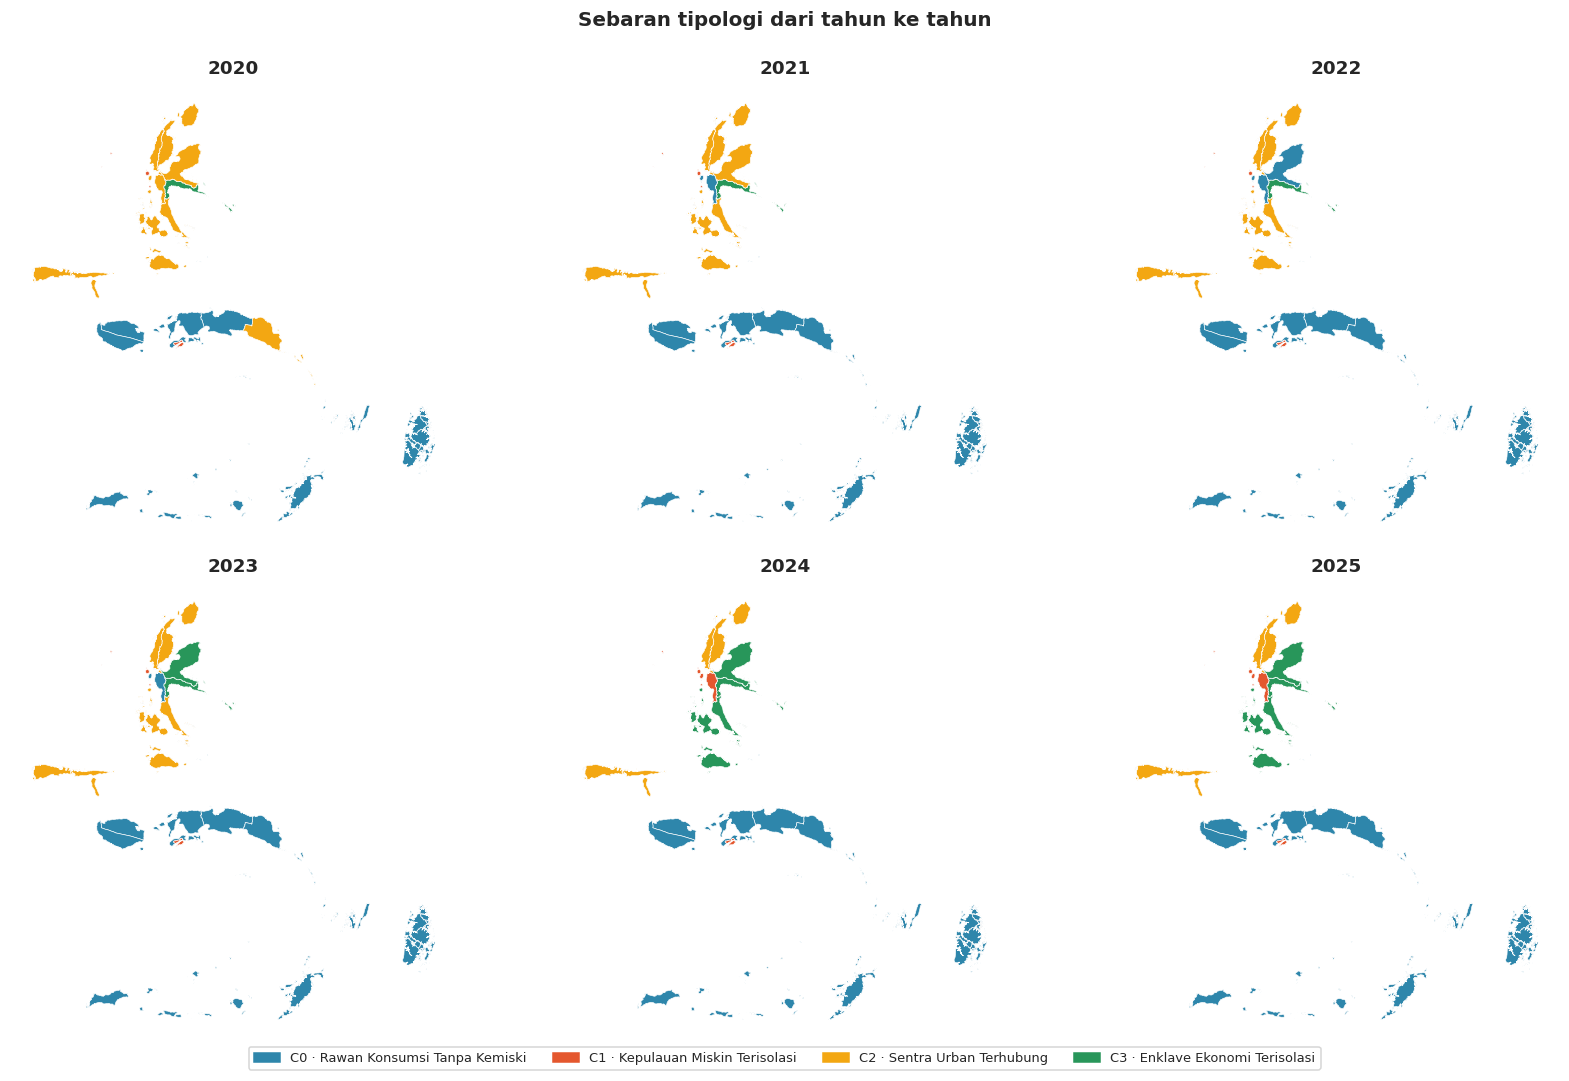

In [34]:
# Peta tipologi tiap tahun
fig, axes = plt.subplots(2, 3, figsize=(15.5, 9.5), sharex=True, sharey=True)
for ax, t in zip(axes.ravel(), TAHUN):
    warna_t = B_urut[t].reindex(peta.wilayah).map(
        lambda c: PALETTE[int(c) % len(PALETTE)]).values
    peta.plot(ax=ax, color=warna_t, edgecolor="white", linewidth=.4)
    ax.set_title(f"{t}", fontsize=12)
    ax.set_axis_off()
handles = [mpatches.Patch(color=PALETTE[c % len(PALETTE)],
                          label=f"C{c} · {TIPOLOGI.get(c, '')[:28]}")
           for c in sorted(set(np.ravel(B_urut.values)))]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8.5,
           bbox_to_anchor=(.5, -.02))
plt.suptitle("Sebaran tipologi dari tahun ke tahun", y=1.0,
             fontsize=13, fontweight="bold")
plt.tight_layout(); simpan(fig, "19_peta_tipologi")

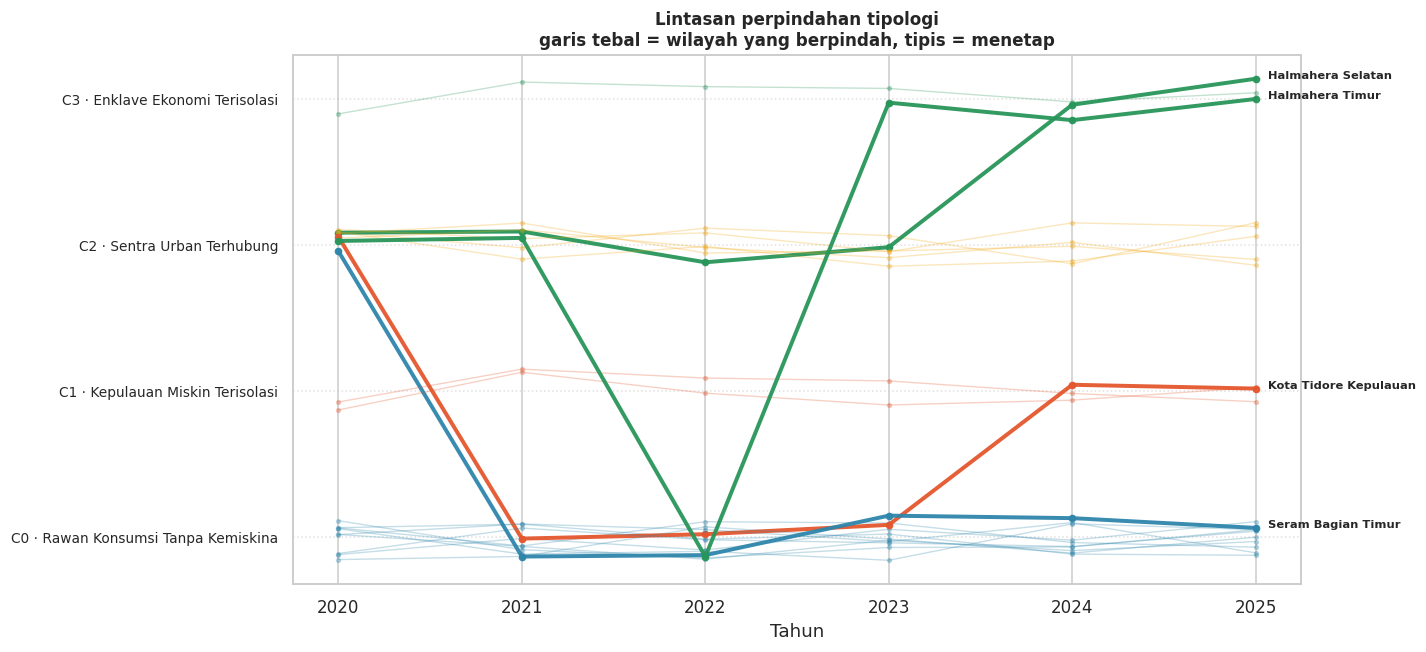

In [35]:
# Diagram alir perpindahan tipologi antar tahun
fig, ax = plt.subplots(figsize=(13, 6))
rng_jitter = np.random.default_rng(RANDOM_STATE)
for w in B_urut.index:
    jalur = B_urut.loc[w].values
    goyang = rng_jitter.uniform(-.16, .16, len(jalur))
    tebal = 2.6 if len(set(jalur)) > 1 else .9
    alpha = .95 if len(set(jalur)) > 1 else .28
    ax.plot(TAHUN, jalur + goyang, lw=tebal, alpha=alpha,
            color=PALETTE[jalur[-1] % len(PALETTE)],
            marker="o", ms=4 if len(set(jalur)) > 1 else 2.5)
    if len(set(jalur)) > 1:
        ax.annotate(w[:22], (TAHUN[-1], jalur[-1] + goyang[-1]), fontsize=7.5,
                    xytext=(8, 0), textcoords="offset points", weight="bold")
ax.set_yticks(sorted(set(np.ravel(B_urut.values))))
ax.set_yticklabels([f"C{c} · {TIPOLOGI.get(c, '')[:30]}"
                    for c in sorted(set(np.ravel(B_urut.values)))], fontsize=9)
ax.set(xlabel="Tahun", title="Lintasan perpindahan tipologi\n"
                             "garis tebal = wilayah yang berpindah, tipis = menetap")
ax.grid(axis="y", ls=":", alpha=.6)
plt.tight_layout(); simpan(fig, "20_peta_tipologi_per_tahun")

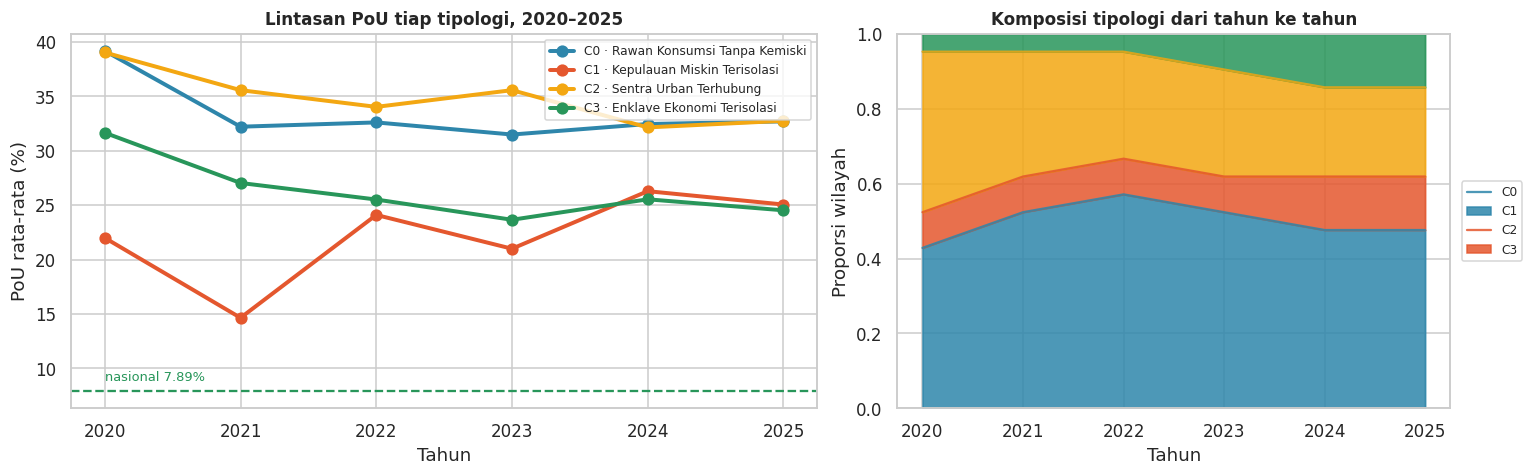

In [36]:
# Lintasan PoU tiap tipologi dan perbandingan stabilitas ketiga rancangan
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4),
                         gridspec_kw={"width_ratios": [1.35, 1]})

ax = axes[0]
for c in sorted(panel.cluster_panel.unique()):
    rata = panel[panel.cluster_panel == c].groupby("tahun").PoU.mean()
    ax.plot(rata.index, rata.values, marker="o", lw=2.6, ms=7,
            color=PALETTE[c % len(PALETTE)], label=f"C{c} · {TIPOLOGI.get(c, '')[:28]}")
ax.axhline(NASIONAL, ls="--", c="#28965A")
ax.text(TAHUN[0], NASIONAL + 1, f"nasional {NASIONAL}%", color="#28965A", fontsize=8.5)
ax.set(xlabel="Tahun", ylabel="PoU rata-rata (%)",
       title="Lintasan PoU tiap tipologi, 2020–2025")
ax.legend(fontsize=8)

ax = axes[1]
komposisi = (B_urut.apply(lambda col: col.value_counts(normalize=True))
             .T.fillna(0).sort_index())
komposisi.plot(kind="area", stacked=True, ax=ax,
               color=[PALETTE[c % len(PALETTE)] for c in komposisi.columns], alpha=.85)
ax.set(xlabel="Tahun", ylabel="Proporsi wilayah", ylim=(0, 1),
       title="Komposisi tipologi dari tahun ke tahun")
ax.legend([f"C{c}" for c in komposisi.columns], fontsize=8, loc="center left",
          bbox_to_anchor=(1.01, .5))
plt.tight_layout(); simpan(fig, "21_lintasan_perpindahan")

**Catatan metodologis yang perlu disebut di laporan.** Clustering panel gabungan
memperlakukan 126 pasangan kabupaten-tahun sebagai observasi terpisah, padahal enam
di antaranya berasal dari kabupaten yang sama. Observasi karenanya tidak sepenuhnya
independen, sehingga nilai Silhouette dan uji signifikansi pada rancangan ini
cenderung optimistis. Rancangan ini dipakai untuk **melacak pergerakan**, bukan untuk
menetapkan tipologi final — penetapan tipologi tetap bersandar pada cross-section
rata-rata yang observasinya benar-benar independen.

---
## Kesimpulan dan Implikasi Kebijakan

**Hambatan ketahanan pangan di Kepulauan Maluku terletak pada distribusi, bukan
produksi.** Kapasitas produksi pangan hampir tidak berkorelasi dengan kecukupan
konsumsi (r = +0,14), sementara isolasi maritim (r = +0,60) dan beban pengeluaran
pangan (r = +0,70) berkorelasi kuat. Lima kabupaten berada tepat di kuadran paradoks:
mampu memproduksi di atas median, namun konsumsinya tetap kurang.

**Empat tipologi menuntut empat pendekatan berbeda:**

| Tipologi | Wilayah | Prioritas intervensi |
|---|---|---|
| Sentra Urban Terhubung | Kota Ambon, Kota Ternate | Pertahankan fungsi hub; optimalkan peran sebagai simpul redistribusi ke kabupaten sekitar |
| Kepulauan Miskin Terisolasi | 11 kabupaten, mayoritas Maluku | Jalur ganda: penguatan ekonomi rumah tangga sekaligus penambahan trayek dan frekuensi kapal |
| Rawan Konsumsi Tanpa Kemiskinan Ekstrem | 6 kabupaten Maluku Utara | **Bukan bantuan tunai.** Penguatan rantai pasok fisik, cadangan pangan daerah, stabilisasi pasokan |
| Enklave Ekonomi Terisolasi | Halmahera Tengah, Halmahera Timur | Menghubungkan pertumbuhan industri dengan layanan dasar; perbaikan akses air minum mendesak |

**Temuan yang paling menantang asumsi umum** adalah tipologi ketiga. Enam kabupaten
Maluku Utara memiliki PoU tertinggi (33,7%) dengan tingkat kemiskinan hanya 6,5% —
jauh di bawah rata-rata wilayah. Penduduknya bukan tidak mampu membeli pangan;
pangannya yang tidak sampai. Program berbasis transfer pendapatan tidak akan
menyentuh akar persoalan di wilayah ini.

**Bagi kerangka swasembada nasional**, temuan ini menyiratkan bahwa target produksi
agregat tidak cukup. Tanpa investasi pada konektivitas maritim — trayek kapal
perintis, kapasitas pelabuhan pengumpan, sistem logistik antar-pulau — peningkatan
produksi nasional tidak akan tercermin pada meja makan penduduk kepulauan.

---
## Keterbatasan

Disampaikan secara terbuka agar pembacaan hasil dilakukan pada porsi yang tepat.

1. **Rasio swasembada absolut tidak dapat dihitung.** Dataset tidak memuat jumlah
   penduduk maupun produksi pangan lokal non-beras (sagu dan umbi), yang justru
   merupakan pangan pokok riil di Maluku. Analisis memakai kapasitas produksi
   relatif, sehingga klaim paradoks bersifat komparatif antar 21 unit — bukan
   pernyataan tentang kecukupan absolut.

2. **Sebanyak 539 sel merupakan hasil rekonstruksi** dari kerusakan format, bukan
   data mentah. Seluruhnya terdokumentasi dan perlu diverifikasi silang ke sumber
   BPS sebelum publikasi.

3. **Indikator jalan kondisi mantap dikeluarkan** karena 64% hilang, sehingga Indeks
   Aksesibilitas Fisik tereduksi menjadi konektivitas maritim saja.

4. **NTP dan tenaga kerja pertanian hanya tersedia di level provinsi**, sehingga
   berfungsi sebagai kontrol dan bukan pembeda antar kabupaten.

5. **Koordinat memakai aproksimasi pusat wilayah**, bukan centroid poligon resmi.
   Jaringan ketetanggaan sebaiknya diperbarui begitu shapefile BPS tersedia.

6. **Dengan 21 unit spasial**, metode yang memerlukan banyak titik kalibrasi
   memiliki ruang gerak terbatas, dan uji non-parametrik berkurang kekuatannya.

---
## Serah Terima ke Tahap Berikutnya

In [37]:
serah = cs[["wilayah", "provinsi", "lat", "lon", "PoU", "IKM", "Isolasi", "IKPP",
            "Tekanan_Pangan", "cluster", "tipologi", "cluster_spasial"]].copy()
for nm, lab in LABEL.items():
    serah[f"label_{nm.split(' ')[0].lower()}"] = lab
serah["silhouette_unit"] = sil_unit
serah["kuadran_paradoks"] = cs.index.isin(paradoks.index)

serah.to_csv("output/hasil_clustering.csv", index=False)
df.to_csv("output/data_bersih_panel.csv", index=False)
cs.to_csv("output/cross_section_2021_2025.csv", index=False)
uji_validasi.to_csv("output/validasi_eksternal.csv")
pd.DataFrame({"indikator_final": FITUR}).to_csv("output/indikator_terpakai.csv", index=False)

print("Berkas tersimpan di folder output/\n")
for f in sorted(os.listdir("output")):
    print(f"   {f:<36} {os.path.getsize('output/' + f):>9,} byte")

print(f"""
Diserahkan kepada:
   · Analisis autokorelasi spasial (Moran's I, LISA, Getis-Ord)
       → gunakan kolom cluster & koordinat; matriks ketetanggaan KNN k={K_TETANGGA}
   · Feature importance (Random Forest, XGBoost, SHAP)
       → gunakan data_bersih_panel.csv dan indikator_terpakai.csv
   · Peramalan PoU per kabupaten
       → tipologi_panel_per_tahun.csv memuat lintasan keanggotaan 2020–2025
   · Sintesis dengan Track B (analisis teks)
       → padankan pada kolom `wilayah`; penamaan wajib identik persis
""")

Berkas tersimpan di folder output/

   audit_pembersihan.csv                   39,073 byte
   cross_section_2021_2025.csv              8,418 byte
   data_bersih_panel.csv                   31,803 byte
   gambar                                   4,096 byte
   hasil_clustering.csv                     4,797 byte
   indikator_terpakai.csv                     156 byte
   perbandingan_metode.csv                    678 byte
   profil_cluster.csv                       1,197 byte
   tipologi_panel_per_tahun.csv               633 byte
   validasi_eksternal.csv                     613 byte

Diserahkan kepada:
   · Analisis autokorelasi spasial (Moran's I, LISA, Getis-Ord)
       → gunakan kolom cluster & koordinat; matriks ketetanggaan KNN k=4
   · Feature importance (Random Forest, XGBoost, SHAP)
       → gunakan data_bersih_panel.csv dan indikator_terpakai.csv
   · Peramalan PoU per kabupaten
       → tipologi_panel_per_tahun.csv memuat lintasan keanggotaan 2020–2025
   · Sintesis dengan Track 

---

Seluruh hasil deterministik dengan `RANDOM_STATE = 42`. Letakkan
`DATASET_GEMASTIK_2026.xlsx` pada folder yang sama dengan notebook, lalu jalankan
seluruh sel berurutan.